# Worum geht es im Projekt?
- Klassifikationsproblem mit 10 Klassen (CIFAR-10 Dataset)
- Bunte (RGB) Bilder, Größe 32×32 Pixel
- 50.000 Bilder zum Trainieren
- 10.000 Bilder zum Testen


# 0. Projektstruktur und Konfiguration
- Hier definieren und erstellen wir die Ordnerstruktur für unser Projekt.
- Dies stellt sicher, dass alle Artefakte (Daten, Modelle, Konfigurationen) sauber gespeichert und wiederverwendet werden können.

In [11]:
import os
import json
import numpy as np
import pandas as pd
from typing import List

# KONSTANTEN IN DRUCKSCHRIFT

# 1. DEFINITION DER ORDNERSTRUKTUR
BASE_DIR: str = "Ablagerung"
RELATIVE_DIRS: List[str] = [
    "config",
    "model",
    "Sempel_data",
    "artifacts_ml"
]

# Erstelle eine Liste aller zu erstellenden Pfade
DIRECTORIES_TO_CHECK: List[str] = [BASE_DIR] + [os.path.join(BASE_DIR, sub_dir) for sub_dir in RELATIVE_DIRS]

print(f"Starte Überprüfung und Erstellung der Ordnerstruktur unter: {BASE_DIR}")
for directory in DIRECTORIES_TO_CHECK:
    os.makedirs(directory, exist_ok=True)
    print(f"🔄 Ordner ist bereit: {directory}")

# 2. DEFINITION DER DATEIPFADE
# Datenpfade
RAW_DATA_PATH = os.path.join(BASE_DIR, "Sempel_data", "cifar10_raw_data.npz")

# Modellpfade
INITIAL_MODEL_PATH = os.path.join(BASE_DIR, "model", "ResNet50_initial.keras")
OPTIMIZED_MODEL_PATH = os.path.join(BASE_DIR, "model", "ResNet50_optimized_on_hard_examples.keras")
HYBRID_MODEL_PATH_64 = os.path.join(BASE_DIR, "model", "hybrid_cnn_lstm_64x64.keras")
HYBRID_MODEL_PATH_32 = os.path.join(BASE_DIR, "model", "hybrid_cnn_lstm_32x32.keras")

# Konfigurationspfade
CLASS_NAMES_PATH = os.path.join(BASE_DIR, "config", "class_names.json")
PLOT_COLORS_PATH = os.path.join(BASE_DIR, "config", "plot_colors.json")

# Artefakt pfade
HISTORY_INITIAL_CSV = os.path.join(BASE_DIR, "artifacts_ml", "initial_model_history.csv")
HISTORY_OPTIMIZED_CSV = os.path.join(BASE_DIR, "artifacts_ml", "optimized_model_history.csv")
GRID_EXAMPLES_HTML = os.path.join(BASE_DIR, "artifacts_ml", "cifar10_grid_examples.html")
MISCLASSIFIED_GRID_OPTIMIZED_HTML = os.path.join(BASE_DIR, "artifacts_ml", "optimized_model_misclassified_grid.html")
CORRECTLY_CLASSIFIED_GRID_HTML = os.path.join(BASE_DIR, "artifacts_ml", "correctly_classified_grid.html")
CONFUSION_ANALYSIS_HTML = os.path.join(BASE_DIR, "artifacts_ml", "optimized_model_confusion_analysis.html")

# 3. KONFIGURATION SPEICHERN
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
if not os.path.exists(CLASS_NAMES_PATH):
    with open(CLASS_NAMES_PATH, 'w') as f:
        json.dump(CLASS_NAMES, f)
    print(f"✅ Klassennamen in '{CLASS_NAMES_PATH}' gespeichert.")

# Farb-Konfiguration erstellen
PLOT_COLORS = {
    "primary": "#1f77b4",
    "secondary": "#ff7f0e",
    "background": "#808080",
    "text": "#333333",
    "grid": "#dddddd",
    "success": "#2ca02c",
    "error": "#d62728"
}
if not os.path.exists(PLOT_COLORS_PATH):
    with open(PLOT_COLORS_PATH, 'w') as f:
        json.dump(PLOT_COLORS, f, indent=4)
    print(f"✅ Plot-Farben in '{PLOT_COLORS_PATH}' gespeichert.")

print("\n✅ Projektstruktur und Konfiguration sind bereit.")

Starte Überprüfung und Erstellung der Ordnerstruktur unter: Ablagerung
🔄 Ordner ist bereit: Ablagerung
🔄 Ordner ist bereit: Ablagerung/config
🔄 Ordner ist bereit: Ablagerung/model
🔄 Ordner ist bereit: Ablagerung/Sempel_data
🔄 Ordner ist bereit: Ablagerung/artifacts_ml

✅ Projektstruktur und Konfiguration sind bereit.


# 1. Daten laden und vorbereiten
- **Optimierung:** Das Skript prüft, ob die Rohdaten bereits gespeichert sind. Wenn ja, werden sie von der Festplatte geladen.
- Wenn nein, werden sie von Keras heruntergeladen und für die zukünftige Verwendung gespeichert.

In [12]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import tensorflow as tf
import plotly.express as px
import scipy.ndimage as ndimage
import shutil
from plotly.subplots import make_subplots
from tqdm.keras import TqdmCallback
from tqdm.notebook import tqdm

from PIL import Image
import numpy as np
import pandas as pd
import os
import json
import time
import pydot
import graphviz
from tensorflow.keras.utils import plot_model
# Keras / TensorFlow Imports
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, Callback
from tensorflow.keras.saving import register_keras_serializable
# Alle Keras Layer in einem Block konsolidiert
from tensorflow.keras.layers import (
    Activation,
    Input,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Lambda,
    BatchNormalization,
    Resizing,
    RandomFlip,
    RandomRotation,
    RandomTranslation,
    RandomZoom,
    RandomBrightness,
    RandomContrast,
    RandomSaturation,
    RandomHue,
    AveragePooling2D,
)
import keras_tuner as kt
from IPython.display import display
try:
    from tqdm.keras import TqdmCallback
except ImportError:
    class TqdmCallback(tf.keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            pass

# Lade Konfigurationen
with open(CLASS_NAMES_PATH, 'r') as f:
    CLASS_NAMES = json.load(f)
with open(PLOT_COLORS_PATH, 'r') as f:
    PLOT_COLORS = json.load(f)

# Matplotlib-Stil anpassen
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = PLOT_COLORS['background']
plt.rcParams['axes.facecolor'] = PLOT_COLORS['background']
plt.rcParams['text.color'] = PLOT_COLORS['text']
plt.rcParams['axes.labelcolor'] = PLOT_COLORS['text']
plt.rcParams['xtick.color'] = PLOT_COLORS['text']
plt.rcParams['ytick.color'] = PLOT_COLORS['text']

# Prüfe, ob die Rohdaten bereits gespeichert sind
if os.path.exists(RAW_DATA_PATH):
    print(f"Lade Rohdaten aus '{RAW_DATA_PATH}'...")
    with np.load(RAW_DATA_PATH) as data:
        train_images, train_labels = data['train_images'], data['train_labels']
        test_images, test_labels = data['test_images'], data['test_labels']
else:
    print("Lade Rohdaten von Keras herunter...")
    (train_images, train_labels), (test_images, test_labels) = cifar10.load_data()
    print(f"Speichere Rohdaten in '{RAW_DATA_PATH}' für zukünftige Verwendung...")
    np.savez_compressed(RAW_DATA_PATH, train_images=train_images, train_labels=train_labels, test_images=test_images, test_labels=test_labels)

train_labels = train_labels.flatten()
test_labels = test_labels.flatten()
print("✅ Daten erfolgreich geladen.")

# Eingrenzung und Normalisierung
N_SAMPLES = 10000
train_images_sliced = train_images[:N_SAMPLES]
train_labels_sliced = train_labels[:N_SAMPLES]
test_images_sliced = test_images[:N_SAMPLES]
test_labels_sliced = test_labels[:N_SAMPLES]

Lade Rohdaten aus 'Ablagerung/Sempel_data/cifar10_raw_data.npz'...
✅ Daten erfolgreich geladen.


# 2. Initiales Modell (ResNet50) - Training oder Laden
- **Optimierung:** Prüft, ob das initiale Modell bereits trainiert wurde. Wenn ja, wird es geladen und das Training übersprungen.

# Auto Tuner

## 2.1 Automatische ideal einstellungs ermitler für den bildersatz

🗑️ Lösche alten Tuner-Projektordner: DL_ERGEBNISSE/vorverarbeitung_hyperparams_tuning

🚀 Starte automatische Hyperparameter-Suche (max. 3 Epochen) in 'DL_ERGEBNISSE'.


/Users/cristallagus/miniconda3/envs/tf-final/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



🎯 Starte das 3-Phasen-Training mit den optimalen Hyperparametern (Hard Example Mining).

--- Phase A: Stabilisierung (3 Epochen, Standard Loss) ---


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]


Phase B: Hard Example Mining (Filterung)
✅ Mining abgeschlossen: Neuer Trainingssatz mit 1200 (1000 Hard / 200 Easy) Bildern erstellt.

Phase C: Gezielte Korrektur (5 Epochen, Focal Loss)


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

✅ Phase C abgeschlossen. Finale Lernphase beendet.


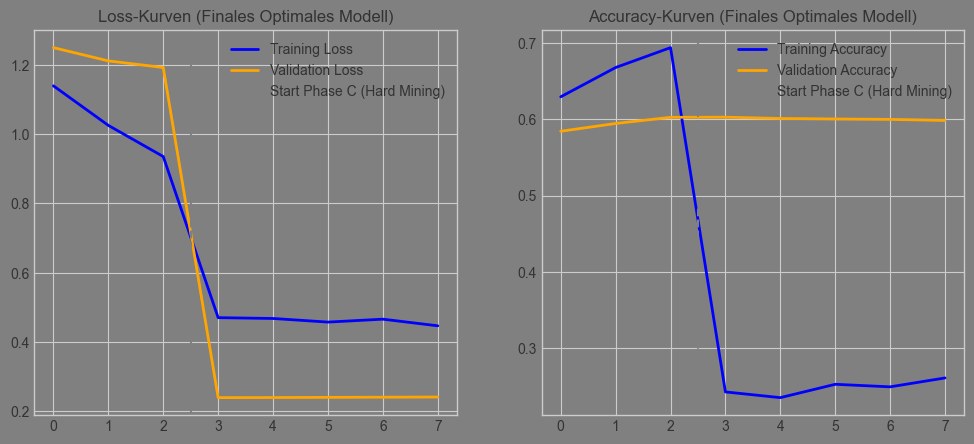


📋 Numerische Daten der Trainingshistorie (Finales Optimales Modell):


,Epoch,accuracy,loss,val_accuracy,val_loss
0,0,0.6296,1.1394,0.5844,1.2496
1,1,0.6680,1.0253,0.5946,1.2114
2,2,0.6941,0.9354,0.6027,1.1922
3,3,0.2425,0.4707,0.6029,0.2400
4,4,0.2350,0.4683,0.6012,0.2402
5,5,0.2525,0.4579,0.6005,0.2408
6,6,0.2492,0.4663,0.6000,0.2413
7,7,0.2608,0.4472,0.5986,0.2417



Finales Optimales Modell Test-Genauigkeit: 59.86 %

🚀 Starte Vorhersage auf Trainingsdaten zur Analyse der Zuverlässigkeit pro Bild...
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 71ms/step

Gesamtzahl der Trainingsbilder: 10000
Korrekt klassifizierte Bilder: 8084
**Prozentuale Zuverlässigkeit (Training): 80.84 %**
Erforderliche Mindestanzahl für 65%: 6500 Bilder.
✅ ZIEL ERREICHT: Das finale Modell erkennt 8084 Bilder (≥ 65%) eindeutig korrekt auf den Trainingsdaten.

RAM-Schonung: 'train_probabilities_final' gelöscht.
🌟 Suche beendet. Dokumentation der optimalen DEFS-Feineinstellungen. 🌟

📋 Optimale Hyperparameter-Werte nach der TUNER-Suche (df_HP_Tabelle)


,Hyperparameter,Beschreibung / Bereich,Optimaler Wert
0,**Parameter**,**Beschreibung / Bereich**,**Optimaler Wert**
1,num_feature_layers,Anzahl der Vorverarbeitungs-Layer (0-3),0
2,learning_rate_head,Lernrate des Klassifikationskopfes,1.0e-04
3,focal_gamma,Focal Loss Gamma Wert (0.5 bis 2.5),1.00
4,use_augmentation,Datenerweiterung verwendet?,Nein
5,---,---,---
6,**DEFS-Feineinstellungen (Global optimal)**,**Bereich (Definiert)**,**Optimaler Wert (Best HPs)**
7,boost_delta,Helligkeitsverschiebung (0.1 bis 0.3),0.25
8,boost_contrast,Kontrastfaktor (2.0 bis 3.0),2.0
9,boost_saturation,Sättigungsfaktor (2.0 bis 3.0),2.5


In [3]:
# 0. KONFIGURATION & DATEN

NUM_CLASSES = len(np.unique(train_labels_sliced))
RESNET50 = ResNet50
train_images_norm = train_images_sliced.astype('float32')
test_images_norm = test_images_sliced.astype('float32')

# Ablagerung Ordner
RESULTS_FOLDER = 'DL_ERGEBNISSE'
TUNER_PROJECT_NAME = 'vorverarbeitung_hyperparams_tuning'
TUNER_PATH = os.path.join(RESULTS_FOLDER, TUNER_PROJECT_NAME)

# 🗑️ KORREKTUR 2: Lösche alten Tuner-Projektordner, um Optimierer-Warnungen zu vermeiden
if os.path.exists(TUNER_PATH):
    print(f"🗑️ Lösche alten Tuner-Projektordner: {TUNER_PATH}")
    # Sicherheitsabfrage oder entfernen, falls der Ordner nicht gelöscht werden soll
    try:
        shutil.rmtree(TUNER_PATH)
    except OSError as e:
        print(f"Fehler beim Löschen des Ordners {TUNER_PATH}: {e}")

os.makedirs(RESULTS_FOLDER, exist_ok=True)

# FOCAL LOSS FUNKTION
@register_keras_serializable()
def categorical_focal_loss(gamma=2.0, alpha=0.25):
    """Focal Loss für Mehrklassen-Klassifizierung."""
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32) # Stelle sicher, dass y_true int ist für One-Hot

        # === KORREKTUR A: One-Hot-Kodierung des y_true Tensors ===
        y_true_oh = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1], dtype=tf.float32)

        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        # 1. Cross-Entropy-Loss (CE)
        # Nutzt jetzt y_true_oh (Shape [Batch, Classes])
        cross_entropy = -y_true_oh * tf.math.log(y_pred)

        # 2. Focal-Loss-Gewichtungsfaktor: (1 - p_t)^gamma
        # p_t ist die Wahrscheinlichkeit der wahren Klasse
        p_t = tf.reduce_sum(y_true_oh * y_pred, axis=-1)
        focal_weight = tf.pow(tf.subtract(1., p_t), gamma)

        # === KORREKTUR B: ERWEITERE DIE DIMENSION für die Multiplikation ===
        # Form: [Batch] -> [Batch, 1]
        focal_weight = tf.expand_dims(focal_weight, axis=-1)

        # 3. Endgültiger Loss
        loss = focal_weight * cross_entropy

        # Reduziere über die Klassen-Dimension und wende Alpha an
        return tf.reduce_sum(alpha * loss, axis=-1)

    return focal_loss_fixed

# 1. PARAMETERISIERTE DEFINITIONEN DER VORVERARBEITUNGS-FUNKTIONEN (DEFS)

# Parameterisierter Combined Color Boost (ANPASSUNG Suchraum)
def create_combined_color_boost_layer(hp):
    delta = hp.Float('boost_delta', min_value=0.1, max_value=0.3, step=0.05)
    contrast = hp.Float('boost_contrast', min_value=2.0, max_value=3.0, step=0.5)
    saturation = hp.Float('boost_saturation', min_value=2.0, max_value=3.0, step=0.5)

    @register_keras_serializable()
    def apply_combined_color_boost_hp(images):
        images = tf.image.adjust_brightness(images, delta=delta)
        images = tf.image.adjust_contrast(images, contrast_factor=contrast)
        images = tf.image.adjust_saturation(images, saturation_factor=saturation)
        return images

    return Lambda(apply_combined_color_boost_hp, name='CombinedColorBoost')

# Parameterisierter Pixel Exact Color Halo (ANPASSUNG Suchraum)
def create_pixel_halo_layer(hp):
    threshold_tight = hp.Float('halo_threshold', min_value=0.35, max_value=0.50, step=0.05)
    boost_delta_internal = hp.Choice('halo_delta_int', values=[0.1, 0.2, 0.3])
    boost_contrast_internal = hp.Choice('halo_contrast_int', values=[3.5, 4.5, 5.5])
    boost_saturation_internal = hp.Choice('halo_saturation_int', values=[3.5, 4.5, 5.5])
    saturation_mask_thresh = hp.Float('halo_sat_mask', min_value=0.1, max_value=0.25, step=0.05)
    mean_color_mask_thresh = hp.Float('halo_mean_mask', min_value=0.05, max_value=0.15, step=0.05)


    @register_keras_serializable()
    def apply_pixel_exact_color_halo_optimized_hp(images):
        orig = tf.cast(images, tf.float32)
        orig_norm = orig / 255.0

        boosted_norm = tf.image.adjust_brightness(orig_norm, delta=boost_delta_internal)
        boosted_norm = tf.image.adjust_contrast(boosted_norm, contrast_factor=boost_contrast_internal)
        boosted_norm = tf.image.adjust_saturation(boosted_norm, saturation_factor=boost_saturation_internal)
        boosted = tf.clip_by_value(boosted_norm, 0.0, 1.0) * 255.0

        gray_norm = tf.image.rgb_to_grayscale(boosted / 255.0)
        sobel = tf.image.sobel_edges(gray_norm)
        dx = tf.squeeze(sobel[..., 0], -1)
        dy = tf.squeeze(sobel[..., 1], -1)
        mag = tf.sqrt(tf.square(dx) + tf.square(dy))
        min_val = tf.reduce_min(mag, axis=[1, 2], keepdims=True)
        max_val = tf.reduce_max(mag, axis=[1, 2], keepdims=True)
        mag_norm = (mag - min_val) / tf.maximum(max_val - min_val, 1e-6)

        edge_mask_raw = tf.cast(mag_norm > threshold_tight, tf.float32)
        edge_mask_4d = tf.expand_dims(edge_mask_raw, axis=-1)
        edge_mask_pooled = tf.nn.max_pool(edge_mask_4d, ksize=[1, 2, 2, 1], strides=[1, 1, 1, 1], padding='SAME')
        edge_mask_smoothed = tf.squeeze(edge_mask_pooled, axis=-1)

        hsv_orig = tf.image.rgb_to_hsv(orig / 255.0)
        saturation = hsv_orig[..., 1]

        combined_condition = tf.logical_and(saturation > saturation_mask_thresh,
                                            tf.reduce_mean(orig_norm, axis=-1) > mean_color_mask_thresh)

        object_mask = tf.cast(combined_condition, tf.float32)
        combined_mask_1ch = edge_mask_smoothed * object_mask
        final_halo_mask_3ch = tf.tile(tf.expand_dims(combined_mask_1ch, axis=-1), [1, 1, 1, 3])

        manual_rgb = tf.constant([0.0, 255.0, 255.0], dtype=tf.float32)
        test_halo_color = tf.expand_dims(tf.expand_dims(manual_rgb, 0), 0)
        halo_color_layer = final_halo_mask_3ch * test_halo_color
        result = tf.where(final_halo_mask_3ch > 0.0, halo_color_layer, orig)
        return tf.clip_by_value(result, 0.0, 255.0)

    return Lambda(apply_pixel_exact_color_halo_optimized_hp, name='PixelExactColorHaloOptimized')

# Nicht-parametrisierte Layer (Fest)
resizing_layer64 = Resizing(64, 64, interpolation='lanczos3', name='Resizing64')
resizing_layer32 = Resizing(32, 32, interpolation='lanczos3', name='Resizing32')
color_pooling_layer = AveragePooling2D(pool_size=(4, 4), strides=(1, 1), padding='same', name='ColorPooling')
resnet_preprocessor_layer = Lambda(tf.keras.applications.resnet50.preprocess_input, name='resnet_preprocessor')

# Mapping der dynamischen Feature Layer (mit ihrer Erstellungsfunktion)
FEATURE_LAYER_CREATORS = {
    'ColorPooling': lambda hp: color_pooling_layer,
    'CombinedColorBoost': create_combined_color_boost_layer,
    'PixelExactColorHaloOptimized': create_pixel_halo_layer,
}


# 2. KERAS TUNER MODELL-GENERATOR (build_model)
def build_model(hp):
    # 2.1 Hyperparameter-Definition
    num_feature_layers = hp.Int('num_feature_layers', min_value=0, max_value=3, step=1)
    feature_choices = list(FEATURE_LAYER_CREATORS.keys())

    learning_rate_head = hp.Choice('learning_rate_head', values=[1e-4, 1.5e-4, 2e-4])

    # Focal Loss Gamma
    hp.Float('focal_gamma', min_value=0.5, max_value=2.5, step=0.5)

    use_augmentation = hp.Boolean('use_augmentation')

    # 2.2 Dynamische Kette erstellen
    model_layers = [Input(shape=(32, 32, 3)), resizing_layer64]

    # Data Augmentation Layer
    if use_augmentation:
        rotation_factor = hp.Float('aug_rotation', min_value=0.05, max_value=0.10, step=0.05)
        model_layers.append(Sequential ([
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(rotation_factor),
            tf.keras.layers.RandomZoom(height_factor=(-0.05, -0.15)),
            tf.keras.layers.RandomTranslation(0.02, 0.02),
            tf.keras.layers.RandomBrightness(0.2),
            tf.keras.layers.RandomContrast(0.2),
        ], name="data_augmentation_layer"))

    # Dynamische Feature-Layer (AUSWAHL & PARAMETERISIERUNG)
    selected_layer_names = set()

    for i in range(3):
        layer_name_key = f'feature_layer_{i}'
        layer_name = hp.Choice(layer_name_key, values=feature_choices)
        if i < num_feature_layers and layer_name not in selected_layer_names:
            layer = FEATURE_LAYER_CREATORS[layer_name](hp)
            model_layers.append(layer)
            selected_layer_names.add(layer_name)

    model_layers.extend([resizing_layer32, resnet_preprocessor_layer])

    # Basis-Modell (ResNet50)
    base_model = RESNET50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    base_model.trainable = False

    # Klassifikations-Kopf
    model_layers.extend([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'), BatchNormalization(), Activation('relu'), Dropout(0.1),
        Dense(64, activation='relu'), BatchNormalization(), Activation('relu'), Dropout(0.1),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    models = Sequential(model_layers)

    # Loss: Standard Cross-Entropy (Tuner bewertet die Basis-Performance)
    models.compile(optimizer=Adam(learning_rate=learning_rate_head),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return models

# KOPIERBARER CALLBACK FÜR KERAS TUNER FORTSCHRITT
class SimpleTunerProgressCallback(Callback):
    def __init__(self, total_max_trials):
        super().__init__()
        self.total_trials = total_max_trials
        self.completed_trials = 0
        self.start_time = time.time()

    def on_trial_begin(self, trial):
        print(f"\n--- Starte Trial {self.completed_trials + 1} von ca. {self.total_trials} ---")

    def on_trial_end(self, trial):
        self.completed_trials += 1
        elapsed_time = time.time() - self.start_time

        try:
             best_val = trial.best_step.get('val_accuracy', 0.0)
        except:
             best_val = 'N/A'

        print(f"✅ Trial {self.completed_trials}/{self.total_trials} abgeschlossen. Laufzeit gesamt: {elapsed_time:.0f}s. Akt. bester Score: {best_val}")

    def on_search_end(self, logs=None):
        final_time = time.time() - self.start_time
        print(f"✅ Hyperparameter-Suche beendet in {final_time:.0f} Sekunden.")

# Max Trials berechnen für den TunerProgressCallback
MAX_TRIALS_GUESS = 30

# 3. HYPERBAND TUNER SETUP UND AUSFÜHRUNG
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=3,
    factor=3,
    hyperband_iterations=2,
    directory=RESULTS_FOLDER,
    project_name=TUNER_PROJECT_NAME,
    overwrite=True
)

print(f"\n🚀 Starte automatische Hyperparameter-Suche (max. 3 Epochen) in '{RESULTS_FOLDER}'.")
simple_progress = SimpleTunerProgressCallback(MAX_TRIALS_GUESS)
# Annahme: TqdmCallback ist importiert
tuner.search(train_images_norm, train_labels_sliced,
            epochs=3,
            validation_data=(test_images_norm, test_labels_sliced),
            callbacks=[simple_progress, EarlyStopping(monitor='val_loss', patience=1, restore_best_weights=True)],
            verbose=0)

# 4. FINALES 3-PHASEN-TRAINING: HARD EXAMPLE MINING MIT FOCAL LOSS
print("\n🎯 Starte das 3-Phasen-Training mit den optimalen Hyperparametern (Hard Example Mining).")

# Das beste Modell abrufen (inkl. Hyperparameter-Werte)
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
models_final = tuner.get_best_models(num_models=1)[0]

initial_learning_rate = best_hps.get('learning_rate_head')
# Behebung des TypeError
focal_gamma_val = best_hps.get('focal_gamma')


# PHASE A: STABILISIERUNG (3 Epochen)
print("\n--- Phase A: Stabilisierung (3 Epochen, Standard Loss) ---")
models_final.compile(optimizer=Adam(learning_rate=initial_learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_phaseA = models_final.fit(
    train_images_norm,
    train_labels_sliced,
    epochs=3,
    validation_data=(test_images_norm, test_labels_sliced),
    verbose=0,
    callbacks=[TqdmCallback(verbose=1)]
)


# PHASE B: HARD EXAMPLE MINING (DATENSELEKTION)
print("\nPhase B: Hard Example Mining (Filterung)")

# 1. Vorhersage und Loss-Berechnung auf allen Trainingsdaten
train_probabilities_mining = models_final.predict(train_images_norm, verbose=0)
loss_fn_mining = tf.keras.losses.SparseCategoricalCrossentropy(reduction=tf.keras.losses.Reduction.NONE)
individual_losses = loss_fn_mining(tf.cast(train_labels_sliced, tf.float32), train_probabilities_mining).numpy()

# 2. Sortierung nach Loss-Wert (Höchster Loss zuerst)
df_losses = pd.DataFrame({
    'loss': individual_losses,
    'index': range(len(individual_losses))
}).sort_values(by='loss', ascending=False)

# 3. SELEKTION: 80% Harte Beispiele (Top 10%), 20% Einfache Beispiele (Top 2%)
TOTAL_SAMPLES = len(train_images_norm)
NUM_SAMPLES_HARD = int(0.10 * TOTAL_SAMPLES)
NUM_SAMPLES_EASY = int(0.02 * TOTAL_SAMPLES)

hard_indices = df_losses.head(NUM_SAMPLES_HARD)['index'].values
# Die 20% Ankerbilder wählen wir aus den 2% besten (niedrigsten Loss)
easy_indices = df_losses.tail(NUM_SAMPLES_EASY)['index'].values

combined_indices = np.concatenate([hard_indices, easy_indices])
np.random.shuffle(combined_indices)

# Erstellung des neuen Datensatzes
train_images_hard = train_images_norm[combined_indices]
train_labels_hard = train_labels_sliced[combined_indices]

print(f"✅ Mining abgeschlossen: Neuer Trainingssatz mit {len(train_images_hard)} ({NUM_SAMPLES_HARD} Hard / {NUM_SAMPLES_EASY} Easy) Bildern erstellt.")
del train_probabilities_mining

# PHASE C: KORREKTUR (5 Epochen, Focal Loss)
print("\nPhase C: Gezielte Korrektur (5 Epochen, Focal Loss)")

# Reduziere die Lernrate für das Fine-Tuning der Fehler (Faktor 10 Reduktion)
LR_HARD_TUNING = initial_learning_rate * 0.1

models_final.compile(optimizer=Adam(learning_rate=LR_HARD_TUNING),
               loss=categorical_focal_loss(gamma=focal_gamma_val),
               metrics=['accuracy'])

# TqdmCallback ist importiert
history_phaseC = models_final.fit(
    train_images_hard, train_labels_hard,
    epochs=5,
    validation_data=(test_images_norm, test_labels_sliced),
    verbose=0,
    callbacks=[TqdmCallback(verbose=1)]
)
print("✅ Phase C abgeschlossen. Finale Lernphase beendet.")

# 5. AUSWERTUNG
df_A = pd.DataFrame(history_phaseA.history)
df_C = pd.DataFrame(history_phaseC.history)
df_C.index += len(df_A)
df_history_final = pd.concat([df_A, df_C]).reset_index().rename(columns={'index': 'Epoch'})
PLOT_COLORS = {'primary': 'blue', 'secondary': 'orange'}
plt.figure(figsize=[12, 5])
# Plot Loss-Kurven
plt.subplot(1, 2, 1)
plt.plot(df_history_final['loss'], color=PLOT_COLORS['primary'], linewidth=2.0, label='Training Loss')
plt.plot(df_history_final['val_loss'], color=PLOT_COLORS['secondary'], linewidth=2.0, label='Validation Loss')
plt.axvline(x=len(df_A)-0.5, color='gray', linestyle='--', label='Start Phase C (Hard Mining)')
plt.legend()
plt.title('Loss-Kurven (Finales Optimales Modell)')
# Plot Accuracy-Kurven
plt.subplot(1, 2, 2)
plt.plot(df_history_final['accuracy'], color=PLOT_COLORS['primary'], linewidth=2.0, label='Training Accuracy')
plt.plot(df_history_final['val_accuracy'], color=PLOT_COLORS['secondary'], linewidth=2.0, label='Validation Accuracy')
plt.axvline(x=len(df_A)-0.5, color='gray', linestyle='--', label='Start Phase C (Hard Mining)')
plt.legend()
plt.title('Accuracy-Kurven (Finales Optimales Modell)')
plt.show()
print("\n📋 Numerische Daten der Trainingshistorie (Finales Optimales Modell):")
display(df_history_final.round(4).head(len(df_history_final)))

# Test-Genauigkeit des finalen Modells (Erneutes Kompilieren mit Standard-Loss für faire Metrik-Bewertung)
models_final.compile(optimizer=Adam(learning_rate=LR_HARD_TUNING),
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

loss_final, accuracy_final = models_final.evaluate(test_images_norm, test_labels_sliced, verbose=0)
print(f"\nFinales Optimales Modell Test-Genauigkeit: {accuracy_final*100:.2f} %")

# 3. Analyse der Einzelbild-Erkennung
print("\n🚀 Starte Vorhersage auf Trainingsdaten zur Analyse der Zuverlässigkeit pro Bild...")
train_probabilities_final = models_final.predict(train_images_norm, verbose=1)
predicted_train_labels_final = np.argmax(train_probabilities_final, axis=1)
true_train_labels = train_labels_sliced
is_correct = (predicted_train_labels_final == true_train_labels)
correct_count = np.sum(is_correct)
total_count = len(true_train_labels)
correct_percentage = (correct_count / total_count) * 100

print(f"\nGesamtzahl der Trainingsbilder: {total_count}")
print(f"Korrekt klassifizierte Bilder: {correct_count}")
print(f"**Prozentuale Zuverlässigkeit (Training): {correct_percentage:.2f} %**")

required_correct = int(0.65 * total_count)
print(f"Erforderliche Mindestanzahl für 65%: {required_correct} Bilder.")

if correct_count >= required_correct:
    print(f"✅ ZIEL ERREICHT: Das finale Modell erkennt {correct_count} Bilder (≥ 65%) eindeutig korrekt auf den Trainingsdaten.")
else:
    print(f"❌ ZIEL VERFEHLT: Das finale Modell erkennt nur {correct_count} Bilder (< 65%) eindeutig korrekt auf den Trainingsdaten.")

# RAM-Schonung
del train_probabilities_final
print("\nRAM-Schonung: 'train_probabilities_final' gelöscht.")
# 4. Erweiterte Tabelle der besten Hyperparameter
print("🌟 Suche beendet. Dokumentation der optimalen DEFS-Feineinstellungen. 🌟")
hp_values = best_hps.values
data = []
fmt = lambda v, f_spec: f"{v:{f_spec}}" if isinstance(v, (float, int)) else str(v)
# A. Modellstruktur & Training
data.append(['**Parameter**', '**Beschreibung / Bereich**', '**Optimaler Wert**'])
data.append(['num_feature_layers', 'Anzahl der Vorverarbeitungs-Layer (0-3)', hp_values.get('num_feature_layers', 0)])
data.append(['learning_rate_head', 'Lernrate des Klassifikationskopfes', fmt(hp_values.get('learning_rate_head', 'N/A'), '.1e')])
data.append(['focal_gamma', 'Focal Loss Gamma Wert (0.5 bis 2.5)', fmt(focal_gamma_val, '.2f')])
use_aug = hp_values.get('use_augmentation', False)
data.append(['use_augmentation', 'Datenerweiterung verwendet?', 'Ja' if use_aug else 'Nein'])
if use_aug:
    data.append(['-> aug_rotation', 'Optimale Rotationsstärke (0.05-0.10)', fmt(hp_values.get('aug_rotation', 'N/A'), '.3f')])
# B. FEINEINSTELLUNGEN DER DEFS
data.append(['---', '---', '---'])
data.append(['**DEFS-Feineinstellungen (Global optimal)**', '**Bereich (Definiert)**', '**Optimaler Wert (Best HPs)**'])
data.append(['boost_delta', 'Helligkeitsverschiebung (0.1 bis 0.3)', fmt(hp_values.get('boost_delta', 'N/A'), '.2f')])
data.append(['boost_contrast', 'Kontrastfaktor (2.0 bis 3.0)', fmt(hp_values.get('boost_contrast', 'N/A'), '.1f')])
data.append(['boost_saturation', 'Sättigungsfaktor (2.0 bis 3.0)', fmt(hp_values.get('boost_saturation', 'N/A'), '.1f')])
data.append(['halo_threshold', 'Kanten-Schwellwert (0.35 bis 0.50)', fmt(hp_values.get('halo_threshold', 'N/A'), '.3f')])
data.append(['halo_delta_int', 'Interner Helligkeits-Boost (0.1/0.2/0.3)', hp_values.get('halo_delta_int', 'N/A')])
data.append(['halo_contrast_int', 'Interner Kontrast-Boost (3.5/4.5/5.5)', hp_values.get('halo_contrast_int', 'N/A')])
data.append(['halo_saturation_int', 'Interner Sättigungs-Boost (3.5/4.5/5.5)', hp_values.get('halo_saturation_int', 'N/A')])
data.append(['halo_sat_mask', 'Sättigungs-Masken-Schw. (0.1 bis 0.25)', fmt(hp_values.get('halo_sat_mask', 'N/A'), '.3f')])
data.append(['halo_mean_mask', 'Mittlere-Farbe-Masken-Schw. (0.05 bis 0.15)', fmt(hp_values.get('halo_mean_mask', 'N/A'), '.3f')])
# C. Layer-Choices
data.append(['---', '---', '---'])
data.append(['**Layer-Choices (Im besten Trial)**', '**Mögliche Choices**', '**Gewählte Option**'])
for i in range(3):
    layer_key = f'feature_layer_{i}'
    layer_val = hp_values.get(layer_key, 'N/A (Nicht im besten Trial verwendet)')
    data.append([layer_key, 'Pooling/Boost/Halo', layer_val])
df_HP_Tabelle_korrigiert = pd.DataFrame(data, columns=['Hyperparameter', 'Beschreibung / Bereich', 'Optimaler Wert'])
print("\n📋 Optimale Hyperparameter-Werte nach der TUNER-Suche (df_HP_Tabelle)")
display(df_HP_Tabelle_korrigiert)

## 2.2 Lernfase nach den erkanten einstellungen

In [5]:
# Einbindung Vollautomatische werte ermitlung ResNet50
# 0. KONFIGURATION & OPTIMALE WERTE EXTRAHIEREN
# (Hier werden die optimalen Werte aus der vorherigen Suche extrahiert)
if 'best_hps' in locals() or 'best_hps' in globals():
    hp_values = best_hps.values
else:
    # FALLBACK: Falls best_hps nicht existiert, werden die Originalwerte verwendet
    print("ACHTUNG: 'best_hps' nicht gefunden. Verwende ursprüngliche Standardwerte.")
    hp_values = {
        # Originalwerte für Layer-Definitionen
        'boost_delta': 0.10, 'boost_contrast': 2.0, 'boost_saturation': 2.5,
        'halo_delta_int': 0.10, 'halo_contrast_int': 4.5, 'halo_saturation_int': 5.5,
        'halo_threshold': 0.450, 'halo_sat_mask': 0.250, 'halo_mean_mask': 0.050,
        # Originalwerte für Modell-Definition
        'num_feature_layers': 2, 'feature_layer_0': 'PixelExactColorHaloOptimized', 'feature_layer_1': 'CombinedColorBoost', 'feature_layer_2': 'PixelExactColorHaloOptimized',
        'use_augmentation': False, 'aug_rotation': 0.10,
        'learning_rate_head': 0.00015,
    }


# ======================================================================
# 0. VARIABLEN-DEFINITIONEN
Auschliesung_datenbank = 175
RESNET50 = ResNet50

train_images_norm = train_images_sliced.astype('float32')
test_images_norm = test_images_sliced.astype('float32')

# 1. DEFINITION DER WIEDERVERWENDBAREN LAYER-OBJEKTE (MIT OPTIMALEN HP-WERTEN)

# Resizing Layer
resizing_layer64 = Resizing(64, 64, interpolation='lanczos3', name='Resizing64')
resizing_layer32 = Resizing(32, 32, interpolation='lanczos3', name='Resizing32')

# ResNet Preprocessor
@register_keras_serializable()
def resnet_preprocess_wrapper(images):
    return tf.keras.applications.resnet50.preprocess_input(images)
resnet_preprocessor_layer = Lambda(resnet_preprocess_wrapper, name='resnet_preprocessor')

# Pooling Layer
color_pooling_layer = AveragePooling2D(pool_size=(4, 4),strides=(1, 1),padding='same',name='ColorPooling')


# 🛠️ Definition der VORVERARBEITUNGSSCHICHTEN (MIT OPTIMALEN HP-WERTEN)

# Datenerweiterung (OPTIONAL & HP-GESTEUERT)
def create_data_augmentation_layer_optimized():
    use_augmentation = hp_values.get('use_augmentation', False)
    if not use_augmentation:
        return None

    rotation = hp_values.get('aug_rotation', 0.10)

    data_augmentation_layer = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(rotation),
        RandomZoom(height_factor=(-0.05, -0.15)),
        RandomTranslation(0.02, 0.02),
        RandomBrightness(0.2),
        RandomContrast(0.2),
    ], name=f"data_aug_R{rotation:.2f}")
    return data_augmentation_layer
data_augmentation_layer_optimized = create_data_augmentation_layer_optimized()


# KONSOLIDIERTES MUSTER (Color Boost) - MIT OPTIMALEN HP-WERTEN
@register_keras_serializable()
def apply_combined_color_boost_optimized(images):
    boost_delta = hp_values.get('boost_delta', 0.10)
    boost_contrast = hp_values.get('boost_contrast', 2.0)
    boost_saturation = hp_values.get('boost_saturation', 2.5)

    images = tf.image.adjust_brightness(images, delta=boost_delta)
    images = tf.image.adjust_contrast(images, contrast_factor=boost_contrast)
    images = tf.image.adjust_saturation(images, saturation_factor=boost_saturation)
    return images
combined_color_boost_layer_optimized = Lambda(apply_combined_color_boost_optimized,
                                             name=f"Boost_d{hp_values.get('boost_delta', 0.10):.2f}_c{hp_values.get('boost_contrast', 2.0):.1f}")


# Pixel-Exact Halo - MIT OPTIMALEN HP-WERTEN
@register_keras_serializable()
def apply_pixel_exact_color_halo_optimized(images):
    orig = tf.cast(images, tf.float32)
    orig_norm = orig / 255.0

    # OPTIMALE WERTE
    halo_delta_int = hp_values.get('halo_delta_int', 0.10)
    halo_contrast = hp_values.get('halo_contrast_int', 4.5)
    halo_saturation = hp_values.get('halo_saturation_int', 5.5)
    threshold_tight = hp_values.get('halo_threshold', 0.450)
    halo_sat_mask = hp_values.get('halo_sat_mask', 0.250)
    halo_mean_mask = hp_values.get('halo_mean_mask', 0.050)

    # 1. Interner Boost
    boosted_norm = tf.image.adjust_brightness(orig_norm, delta=halo_delta_int)
    boosted_norm = tf.image.adjust_contrast(boosted_norm, contrast_factor=halo_contrast)
    boosted_norm = tf.image.adjust_saturation(boosted_norm, saturation_factor=halo_saturation)
    boosted = tf.clip_by_value(boosted_norm, 0.0, 1.0) * 255.0

    # Sobel
    gray_norm = tf.image.rgb_to_grayscale(boosted / 255.0)
    sobel = tf.image.sobel_edges(gray_norm)
    dx = tf.squeeze(sobel[..., 0], -1)
    dy = tf.squeeze(sobel[..., 1], -1)
    mag = tf.sqrt(tf.square(dx) + tf.square(dy))

    min_val = tf.reduce_min(mag, axis=[1, 2], keepdims=True)
    max_val = tf.reduce_max(mag, axis=[1, 2], keepdims=True)
    mag_norm = (mag - min_val) / tf.maximum(max_val - min_val, 1e-6)

    # Kantenmaske mit optimalem Schwellwert
    edge_mask_raw = tf.cast(mag_norm > threshold_tight, tf.float32)
    edge_mask_4d = tf.expand_dims(edge_mask_raw, axis=-1)

    edge_mask_pooled = tf.nn.max_pool(
        edge_mask_4d,
        ksize=[1, 2, 2, 1],
        strides=[1, 1, 1, 1],
        padding='SAME'
    )
    edge_mask_smoothed = tf.squeeze(edge_mask_pooled, axis=-1)

    hsv_orig = tf.image.rgb_to_hsv(orig / 255.0)
    saturation = hsv_orig[..., 1]
    brightness_norm = tf.reduce_mean(orig_norm, axis=-1)

    # Objektmaske mit optimalen Schwellwerten
    combined_condition = tf.logical_and(
        saturation > halo_sat_mask,
        brightness_norm > halo_mean_mask
    )

    object_mask = tf.cast(combined_condition, tf.float32)
    combined_mask_1ch = edge_mask_smoothed * object_mask
    final_halo_mask_3ch = tf.tile(tf.expand_dims(combined_mask_1ch, -1), [1, 1, 1, 3])
    manual_rgb = tf.constant([0.0, 255.0, 255.0], dtype=tf.float32)
    test_halo_color = tf.expand_dims(tf.expand_dims(manual_rgb, 0), 0)
    halo_color_layer = final_halo_mask_3ch * test_halo_color
    result = tf.where(final_halo_mask_3ch > 0.0, halo_color_layer, orig)
    return tf.clip_by_value(result, 0.0, 255.0)
contour_layer_optimized = tf.keras.layers.Lambda(apply_pixel_exact_color_halo_optimized,
                                                name=f"Halo_t{hp_values.get('halo_threshold', 0.450):.3f}_s{hp_values.get('halo_sat_mask', 0.250):.3f}")

# Mapping der Layer-Namen zu den Layer-Objekten (für die dynamische Konstruktion)
LAYER_OBJECT_MAPPING = {
    'ColorPooling': color_pooling_layer,
    'CombinedColorBoost': combined_color_boost_layer_optimized,
    'PixelExactColorHaloOptimized': contour_layer_optimized,
}
# ===============================================================================


# 2. MODELL-DEFINITION (DYNAMISCH BASIEREND AUF BEST HPS)

print("📝 Erstelle das finale Modell basierend auf optimalen Hyperparametern:")
model_layers = [Input(shape=(32, 32, 3))]

# Hinzufügen der Resizing Layer (fest)
model_layers.append(resizing_layer64)

# Data Augmentation Layer (optional)
if data_augmentation_layer_optimized:
    model_layers.append(data_augmentation_layer_optimized)

# Dynamische Feature-Layer (AUSWAHL & REIHENFOLGE)
num_feature_layers = hp_values.get('num_feature_layers', 2)
selected_layers = []

for i in range(num_feature_layers):
    layer_key = f'feature_layer_{i}'
    layer_name = hp_values.get(layer_key)
    if layer_name in LAYER_OBJECT_MAPPING:
        # Fügt den Layer hinzu, wenn er ausgewählt wurde
        model_layers.append(LAYER_OBJECT_MAPPING[layer_name])
        selected_layers.append(layer_name)

print(f"-> Verwendete Feature-Layer: {selected_layers}")

# Hinzufügen der Resizing und Preprocessor Layer (fest)
model_layers.extend([resizing_layer32, resnet_preprocessor_layer])

# Basis-Modell (ResNet50)
base_model = RESNET50(weights='imagenet',
                      include_top=False,
                      input_shape=(32, 32, 3))
base_model.trainable = False # Zuerst einfrieren

# Klassifikations-Kopf
model_layers.extend([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.1), # Dropout-Werte aus der Suche könnten hier auch verwendet werden
    Dense(64, activation='relu'),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.1),
    Dense(NUM_CLASSES, activation='softmax')
])

models = Sequential(model_layers)

# 4. PHASE 1: Training des Classifier-Kopfes (Head)
print("\nPhase 1: Training des Classifier-Kopfes (Head)")

learning_rate_head_opt = hp_values.get('learning_rate_head', 0.00015)
models.compile(optimizer=Adam(learning_rate=learning_rate_head_opt),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stopping_head = EarlyStopping(monitor='val_loss',
                                    patience=3,
                                    restore_best_weights=True,
                                    verbose=1)

history_head = models.fit(train_images_norm, train_labels_sliced,
                          epochs=10,
                          validation_data=(test_images_norm , test_labels_sliced),
                          callbacks=[TqdmCallback(verbose=1),
                                     early_stopping_head,
                                     ],
                          verbose=0
                          )

# 5. PHASE 2: Fine-Tuning des Basismodells
print("\nPhase 2: Fine-Tuning der letzten 175 ResNet-Layer")

base_model.trainable = True
for layer in base_model.layers[:-Auschliesung_datenbank]:
    layer.trainable = False

learning_rate_ft_orig = 0.00002

models.compile(optimizer=Adam(learning_rate=learning_rate_ft_orig),
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

early_stopping_ft = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)

INITIAL_MODEL_PATH = 'best_optimized_model.keras'
HISTORY_INITIAL_CSV = 'history_optimized.csv'


history_ft = models.fit(train_images_norm, train_labels_sliced,
                        epochs=50,
                        validation_data=(test_images_norm, test_labels_sliced),
                        callbacks=[TqdmCallback(verbose=1),
                                   early_stopping_ft,
                                   ModelCheckpoint(filepath=INITIAL_MODEL_PATH,
                                                   monitor='val_loss',
                                                   save_best_only=True,
                                                   verbose=1)],
                        verbose=0)
print(f"\n✅ Training abgeschlossen. Modell in '{INITIAL_MODEL_PATH}' gespeichert.")

# 6. HISTORIE ZUSAMMENFÜHREN UND SPEICHERN
df_head = pd.DataFrame(history_head.history)
df_ft = pd.DataFrame(history_ft.history)
df_ft.index += len(df_head)
df_history_initial = pd.concat([df_head, df_ft]).reset_index().rename(columns={'index': 'Epoch'})
df_history_initial.to_csv(HISTORY_INITIAL_CSV, index=False)
print(f"✅ Trainingshistorie in '{HISTORY_INITIAL_CSV}' gespeichert.")

📝 Erstelle das finale Modell basierend auf optimalen Hyperparametern:
-> Verwendete Feature-Layer: []

Phase 1: Training des Classifier-Kopfes (Head)


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Restoring model weights from the end of the best epoch: 9.

Phase 2: Fine-Tuning der letzten 175 ResNet-Layer


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]


Epoch 1: val_loss improved from None to 1.85697, saving model to best_optimized_model.keras

Epoch 2: val_loss improved from 1.85697 to 1.84715, saving model to best_optimized_model.keras

Epoch 3: val_loss improved from 1.84715 to 1.63634, saving model to best_optimized_model.keras

Epoch 4: val_loss improved from 1.63634 to 1.53416, saving model to best_optimized_model.keras

Epoch 5: val_loss improved from 1.53416 to 1.46113, saving model to best_optimized_model.keras

Epoch 6: val_loss improved from 1.46113 to 1.37821, saving model to best_optimized_model.keras

Epoch 7: val_loss improved from 1.37821 to 1.33912, saving model to best_optimized_model.keras

Epoch 8: val_loss improved from 1.33912 to 1.28683, saving model to best_optimized_model.keras

Epoch 9: val_loss improved from 1.28683 to 1.24882, saving model to best_optimized_model.keras

Epoch 10: val_loss improved from 1.24882 to 1.24113, saving model to best_optimized_model.keras

Epoch 11: val_loss improved from 1.24113 

## 2.1.1 Manuel Optisch Nachfolziebarkeit der Einstellung

In [ ]:
#Manuelle Optisch Nachfolzibare einstellung del Lernbildes

IMAGE_INDEX = 4

# Sicherstellen, dass die Daten 32x32x3
if 'test_images' in globals() and test_images.ndim == 4:
    ORIGINAL_IMAGE = test_images[IMAGE_INDEX]
    CLASS_LABEL = test_labels[IMAGE_INDEX].item()
else:
    # Fallback für den Fall, dass die Daten nicht geladen wurden (um das Muster ausführbar zu halten)
    ORIGINAL_IMAGE = np.random.randint(0, 256, (32, 32, 3), dtype=np.uint8)
    CLASS_LABEL = 0
    print("ACHTUNG: 'test_images' nicht gefunden. Visualisierung nutzt zufälliges Dummy-Bild.")
train_images_norm = train_images_sliced.astype('float32')  # / 255.0
test_images_norm = test_images_sliced.astype('float32')    # / 255.0

# Resizing Layer
resizing_layer64 = Resizing(64, 64, interpolation='lanczos3', name='Resizing64')
resizing_layer32 = Resizing(32, 32, interpolation='lanczos3', name='Resizing32')

# Registriertes Wrapper-Muster für den ResNet Preprocessor
@register_keras_serializable()
def resnet_preprocess_wrapper(images):
    return tf.keras.applications.resnet50.preprocess_input(images)
resnet_preprocessor_layer = Lambda(resnet_preprocess_wrapper, name='resnet_preprocessor')

# Pooling Layer
color_pooling_layer = AveragePooling2D(pool_size=(4, 4),strides=(1, 1),padding='same',name='ColorPooling')

# 🛠️ Definition der Vorverarbeitungsschichten (Vereinfacht)
def create_data_augmentation_layer():
    data_augmentation_layer = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(0.10),
        RandomZoom(height_factor=(-0.05, -0.15)),
        RandomTranslation(0.02, 0.02),
        RandomBrightness(0.2),
        RandomContrast(0.2),
    ], name="data_augmentation_layer")
    return data_augmentation_layer
data_augmentation_layer = create_data_augmentation_layer()

# KONSOLIDIERTES MUSTER (Color Boost)
@register_keras_serializable()
def apply_combined_color_boost(images):
    boost_delta = 0.10
    boost_contrast = 2.0
    boost_saturation = 2.5
    images = tf.image.adjust_brightness(images, delta=boost_delta)
    images = tf.image.adjust_contrast(images, contrast_factor=boost_contrast)
    images = tf.image.adjust_saturation(images, saturation_factor=boost_saturation)
    return images
combined_color_boost_layer = Lambda(apply_combined_color_boost, name='CombinedColorBoost')

# Pixel-Exact Halo
@register_keras_serializable()
def apply_pixel_exact_color_halo_optimized(images):

    orig = tf.cast(images, tf.float32)
    orig_norm = orig / 255.0

    halo_delta_int = 0.10
    halo_contrast = 4.5
    halo_saturation = 5.5
    boosted_norm = tf.image.adjust_brightness(orig_norm, delta=halo_delta_int)
    boosted_norm = tf.image.adjust_contrast(boosted_norm, contrast_factor=halo_contrast)
    boosted_norm = tf.image.adjust_saturation(boosted_norm, saturation_factor=halo_saturation)
    boosted = tf.clip_by_value(boosted_norm, 0.0, 1.0) * 255.0

    # Sobel
    gray_norm = tf.image.rgb_to_grayscale(boosted / 255.0)
    sobel = tf.image.sobel_edges(gray_norm)
    dx = tf.squeeze(sobel[..., 0], -1)
    dy = tf.squeeze(sobel[..., 1], -1)
    mag = tf.sqrt(tf.square(dx) + tf.square(dy))
    mag = tf.squeeze(mag, axis=-1)

    min_val = tf.reduce_min(mag, axis=[1, 2], keepdims=True)
    max_val = tf.reduce_max(mag, axis=[1, 2], keepdims=True)
    mag_norm = (mag - min_val) / tf.maximum(max_val - min_val, 1e-6)

    halo_threshold = 0.450
    threshold_tight = halo_threshold
    edge_mask_raw = tf.cast(mag_norm > threshold_tight, tf.float32)
    edge_mask_4d = tf.expand_dims(edge_mask_raw, axis=-1)

    edge_mask_pooled = tf.nn.max_pool(
        edge_mask_4d,
        ksize=[1, 2, 2, 1],
        strides=[1, 1, 1, 1],
        padding='SAME'
    )
    edge_mask_smoothed = tf.squeeze(edge_mask_pooled, axis=-1)

    hsv_orig = tf.image.rgb_to_hsv(orig / 255.0)
    saturation = hsv_orig[..., 1]
    brightness_norm = tf.reduce_mean(orig_norm, axis=-1)

    halo_sat_mask = 0.250
    halo_mean_mask = 0.050
    combined_condition = tf.logical_and(
        saturation > halo_sat_mask,
        brightness_norm > halo_mean_mask
    )

    object_mask = tf.cast(combined_condition, tf.float32)
    combined_mask_1ch = edge_mask_smoothed * object_mask
    final_halo_mask_3ch = tf.tile(tf.expand_dims(combined_mask_1ch, -1), [1, 1, 1, 3])
    manual_rgb = tf.constant([0.0, 255.0, 255.0], dtype=tf.float32)
    test_halo_color = tf.expand_dims(tf.expand_dims(manual_rgb, 0), 0)
    halo_color_layer = final_halo_mask_3ch * test_halo_color
    result = tf.where(final_halo_mask_3ch > 0.0, halo_color_layer, orig)
    return tf.clip_by_value(result, 0.0, 255.0)
contour_layer_optimized = tf.keras.layers.Lambda(apply_pixel_exact_color_halo_optimized,name='PixelExactColorHaloOptimized')

# Dominant-Dark Halo Layer
@register_keras_serializable()
def apply_dominant_dark_color_halo_fixed(images):

    orig = tf.cast(images, tf.float32)
    orig_norm = orig / 255.0

    boosted_norm = tf.image.adjust_brightness(orig_norm, delta=0.2)
    boosted_norm = tf.image.adjust_contrast(boosted_norm, contrast_factor=5.5)
    boosted_norm = tf.image.adjust_saturation(boosted_norm, saturation_factor=5.5)
    hsv_boosted = tf.image.rgb_to_hsv(tf.clip_by_value(boosted_norm, 0.0, 1.0))

    hue = hsv_boosted[..., 0]
    saturation = hsv_boosted[..., 1]
    value = hsv_boosted[..., 2]

    SAT_MIN = 0.65
    VAL_MIN = 0.05
    TOLERANCE = 0.15

    quantized_image = tf.zeros_like(orig_norm)

    red_mask_low = tf.logical_and(hue >= 0.0, hue <= TOLERANCE)
    red_mask_high = tf.logical_and(hue >= 1.0 - TOLERANCE, hue <= 1.0)
    red_mask = tf.logical_or(red_mask_low, red_mask_high)
    red_mask = tf.logical_and(red_mask, saturation > SAT_MIN)
    red_mask = tf.logical_and(red_mask, value > VAL_MIN)
    quantized_image = tf.where(tf.expand_dims(red_mask, -1),
                               tf.constant([1.0, 0.0, 0.0]), quantized_image)

    green_mask = tf.logical_and(hue >= (1/3 - TOLERANCE), hue <= (1/3 + TOLERANCE))
    green_mask = tf.logical_and(green_mask, saturation > SAT_MIN)
    green_mask = tf.logical_and(green_mask, value > VAL_MIN)
    quantized_image = tf.where(tf.expand_dims(green_mask, -1),
                               tf.constant([0.0, 1.0, 0.0]), quantized_image)

    blue_mask = tf.logical_and(hue >= (2/3 - TOLERANCE), hue <= (2/3 + TOLERANCE))
    blue_mask = tf.logical_and(blue_mask, saturation > SAT_MIN)
    blue_mask = tf.logical_and(blue_mask, value > VAL_MIN)
    quantized_image = tf.where(tf.expand_dims(blue_mask, -1),
                               tf.constant([0.0, 0.0, 1.0]), quantized_image)

    white_mask = tf.logical_and(value > 0.90, saturation < 0.20)
    quantized_image = tf.where(tf.expand_dims(white_mask, -1),
                               tf.constant([1.0, 1.0, 1.0]), quantized_image)

    quantized_4d = quantized_image
    dilated_quantized = tf.nn.max_pool(quantized_4d, ksize=3, strides=1, padding='SAME')
    difference = tf.reduce_sum(tf.abs(dilated_quantized - quantized_4d), axis=-1)
    contour_mask_1ch = tf.cast(difference > 0.01, tf.float32)

    contour_mask_4d = tf.expand_dims(tf.expand_dims(contour_mask_1ch, 0), -1)
    thick_contour_mask_4d = tf.nn.max_pool(contour_mask_4d, ksize=5, strides=1, padding='SAME')
    thick_contour_mask_1ch = tf.squeeze(tf.squeeze(thick_contour_mask_4d, axis=-1), axis=0)

    orig_4d = tf.expand_dims(orig, 0)
    neg_orig_4d = -orig_4d
    neg_dominant_dark_color_4d = tf.nn.max_pool(neg_orig_4d, ksize=3, strides=1, padding='SAME')
    dominant_dark_color_4d = -neg_dominant_dark_color_4d
    dominant_dark_color_3ch = tf.squeeze(dominant_dark_color_4d, axis=0)

    final_halo_mask_3ch = tf.tile(tf.expand_dims(thick_contour_mask_1ch, -1), [1, 1, 1, 3])
    halo_color_layer = final_halo_mask_3ch * dominant_dark_color_3ch

    inverse_mask = 1.0 - final_halo_mask_3ch
    original_without_halo_area = orig * inverse_mask

    result = original_without_halo_area + halo_color_layer

    return tf.clip_by_value(result, 0.0, 255.0)
contour_layer_dominant_dark_color_halo_fixed = tf.keras.layers.Lambda(apply_dominant_dark_color_halo_fixed,name='DarkestColorHaloFixed')

@register_keras_serializable()
def apply_center_weighted_mask(images):
    H, W = images.shape[1], images.shape[2]
    center = H / 2.0
    Y, X = np.ogrid[0:H, 0:W]
    distance = np.sqrt((Y - center)**2 + (X - center)**2)
    max_dist = np.sqrt(center**2 + center**2)
    mask = 1.0 - (0.5 * (distance / max_dist))
    mask = mask[:, :, np.newaxis].astype(np.float32)
    masked_images = images * mask
    return masked_images
center_mask_layer = tf.keras.layers.Lambda(apply_center_weighted_mask, name='CenterWeightedMask')

# Gaussian Filter
@register_keras_serializable()
def apply_gaussian_filter_to_batch(images):
    input_shape = images.shape
    sigma = (0, 1.5, 1.5, 0)
    blurred_images = tf.py_function(
        lambda x: ndimage.gaussian_filter(x, sigma=sigma).astype(np.float32),
        [images],
        tf.float32
    )
    blurred_images.set_shape(input_shape)
    return blurred_images
gaussian_filter_layer = Lambda(apply_gaussian_filter_to_batch, name='gaussian_pre_filter')

# Kantenbasierte Maskierung
@register_keras_serializable()
def apply_edge_contour_mask_v3(images):

    if images.shape.rank != 4 or images.shape[-1] != 3:
        return images

    gray_images = tf.image.rgb_to_grayscale(images)
    sobel_result = tf.image.sobel_edges(gray_images)
    sobel_dx = tf.squeeze(sobel_result[..., 0], -1)
    sobel_dy = tf.squeeze(sobel_result[..., 1], -1)

    edge_magnitude = tf.sqrt(tf.square(sobel_dx) + tf.square(sobel_dy))

    max_val = tf.reduce_max(edge_magnitude, axis=[1, 2], keepdims=True)
    min_val = tf.reduce_min(edge_magnitude, axis=[1, 2], keepdims=True)

    safe_max_min = tf.maximum(max_val - min_val, 1e-6)
    normalized_edges = (edge_magnitude - min_val) / safe_max_min

    threshold = 0.1
    binary_contour = tf.cast(normalized_edges > threshold, tf.float32)
    mask = binary_contour[..., tf.newaxis]

    object_mask_soft = tf.nn.avg_pool(
        mask,
        ksize=(1, 5, 5, 1),
        strides=(1, 1, 1, 1),
        padding='SAME'
    )

    average_color = tf.reduce_mean(images, axis=[1, 2], keepdims=True)
    background_flat = tf.ones_like(images) * average_color

    mask_3ch = tf.tile(object_mask_soft, [1, 1, 1, 3])

    masked_images = (images * mask_3ch) + (background_flat * (1.0 - mask_3ch))

    return masked_images
edge_contour_layer = Lambda(apply_edge_contour_mask_v3, name='CenterObjectMask')

# =====================================================================
# LAYER MAPPING

LAYER_MAPPING = {
    'Resizing64': resizing_layer64,
    'PixelExactColorHaloOptimized': contour_layer_optimized,
    'DarkestColorHaloFixed': contour_layer_dominant_dark_color_halo_fixed,
    'CombinedColorBoost': combined_color_boost_layer,
    'ColorPooling': color_pooling_layer,
    'gaussian_pre_filter': gaussian_filter_layer,
    'data_augmentation': data_augmentation_layer,
    'Resizing32': resizing_layer32,
    'CenterWeightedMask': center_mask_layer,
    'CenterObjectMask': edge_contour_layer,
    'resnet_preprocessor': resnet_preprocessor_layer,
}

# =====================================================================
# Kontrollblock der aktiven Pipeline

ACTIVE_LAYERS_TO_PLOT = [
    'Resizing64',
    'data_augmentation',
    'ColorPooling',
    'Resizing32',
    'CenterObjectMask',
    'CenterWeightedMask',
    'resnet_preprocessor',
]
# Dynamische Verarbeitung
images_to_plot = []

current_image = ORIGINAL_IMAGE[np.newaxis, ...].astype('float32')
images_to_plot.append({
    "title": f"Originalbild\n({current_image.shape[1]}x{current_image.shape[2]})",
    "tensor": current_image[0],
    "scale": "0-255",
    "is_start": True
})

for step_name in ACTIVE_LAYERS_TO_PLOT:
    if step_name not in LAYER_MAPPING:
        continue

    layer = LAYER_MAPPING[step_name]
    is_aug = step_name == 'data_augmentation'

    if is_aug:
        current_image = layer(current_image, training=True)
    else:
        current_image = layer(current_image)

    scale = "ResNet-Norm" if step_name == 'resnet_preprocessor' else "0-255"

    images_to_plot.append({
        "title": f"{step_name}\n({current_image.shape[1]}x{current_image.shape[2]})",
        "tensor": current_image[0],
        "scale": scale,
        "is_start": False
    })

# =====================================================================
# Plot
num_plots = len(images_to_plot)

if num_plots == 0:
    print("Keine aktiven Schritte zum Plotten gefunden.")
else:
    fig, axes = plt.subplots(1, num_plots, figsize=(4.5 * num_plots, 5), facecolor=PLOT_COLORS['background'])

    if num_plots == 1:
        axes = [axes]
    class_name_display = CLASS_NAMES[CLASS_LABEL] if 'CLASS_NAMES' in globals() else f'Label {CLASS_LABEL}'
    fig.suptitle(
        f"Optische Darstellung der Vorverarbeitungskette für Bild {IMAGE_INDEX} ({class_name_display})",
        fontsize=16, color=PLOT_COLORS['text'])

    for i, plot_data in enumerate(images_to_plot):
        ax = axes[i]
        tensor = plot_data["tensor"]

        if plot_data["scale"] == "ResNet-Norm":
            min_val = tf.reduce_min(tensor)
            max_val = tf.reduce_max(tensor)
            if max_val - min_val == 0:
                display_image = tf.zeros_like(tensor)
            else:
                display_image = (tensor - min_val) / (max_val - min_val) * 255
        else:
            display_image = tf.clip_by_value(tensor, 0, 255)
        display_image = display_image.numpy().astype(np.uint8)
        ax.imshow(display_image, interpolation='nearest')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis("off")
        ax.set_title(plot_data["title"], color=PLOT_COLORS['text'],
                     bbox=dict(facecolor=PLOT_COLORS['primary'], alpha=0.6, edgecolor='none'))
        if plot_data["is_start"]:
            ax.patch.set_facecolor(PLOT_COLORS['background'])
            for spine in ax.spines.values():
                spine.set_linewidth(3)
                spine.set_color(PLOT_COLORS['primary'])
            ax.text(
                x=1, y=31, s=class_name_display.upper(), color='white', fontsize=10, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.6, pad=1))

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## 2.1.2 Maunelle ResNet50 mit Augmentierung
 ResNet50-Musters, um die Generalisierungsfähigkeit zu erhöhen:

In [ ]:
# Manuelle ResNet50 vor Lernen mit 5 epochen und nach lernen mit 15 epochen
# 0. VARIABLEN-DEFINITIONEN

Auschliesung_datenbank = 175
RESNET50 = ResNet50
train_images_norm = train_images_sliced.astype('float32') #/ 255.0 # resnet_preprocessor_layer,
test_images_norm = test_images_sliced.astype('float32')# / 255.0

# 1. DEFINITION DER WIEDERVERWENDBAREN LAYER-OBJEKTE

# Resizing Layer
resizing_layer64 = Resizing(64, 64, interpolation='lanczos3', name='Resizing64')
resizing_layer32 = Resizing(32, 32, interpolation='lanczos3', name='Resizing32')

# Registriertes Wrapper-Muster für den ResNet Preprocessor
@register_keras_serializable()
def resnet_preprocess_wrapper(images):
    return tf.keras.applications.resnet50.preprocess_input(images)
resnet_preprocessor_layer = Lambda(resnet_preprocess_wrapper, name='resnet_preprocessor')

# Pooling Layer
color_pooling_layer = AveragePooling2D(pool_size=(4, 4),strides=(1, 1),padding='same',name='ColorPooling')

# 🛠️ Definition der Vorverarbeitungsschichten (Vereinfacht)
def create_data_augmentation_layer():
    data_augmentation_layer = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(0.10),
        RandomZoom(height_factor=(-0.05, -0.15)),
        RandomTranslation(0.02, 0.02),
        RandomBrightness(0.2),
        RandomContrast(0.2),
    ], name="data_augmentation_layer")
    return data_augmentation_layer
data_augmentation_layer = create_data_augmentation_layer()

# KONSOLIDIERTES MUSTER (Color Boost)
@register_keras_serializable()
def apply_combined_color_boost(images):
    images = tf.image.adjust_brightness(images, delta=0.2)
    images = tf.image.adjust_contrast(images, contrast_factor=2.5)
    images = tf.image.adjust_saturation(images, saturation_factor=2.5)
    return images
combined_color_boost_layer = Lambda(apply_combined_color_boost, name='CombinedColorBoost')

# Pixel-Exact Halo
@register_keras_serializable()
def apply_pixel_exact_color_halo_optimized(images):

    orig = tf.cast(images, tf.float32)
    orig_norm = orig / 255.0

    # Boosting
    boosted_norm = tf.image.adjust_brightness(orig_norm, delta=0.2)
    boosted_norm = tf.image.adjust_contrast(boosted_norm, contrast_factor=4.5)
    boosted_norm = tf.image.adjust_saturation(boosted_norm, saturation_factor=4.5)
    boosted = tf.clip_by_value(boosted_norm, 0.0, 1.0) * 255.0

    # Sobel
    gray_norm = tf.image.rgb_to_grayscale(boosted / 255.0)
    sobel = tf.image.sobel_edges(gray_norm)
    dx = tf.squeeze(sobel[..., 0], -1)
    dy = tf.squeeze(sobel[..., 1], -1)
    mag = tf.sqrt(tf.square(dx) + tf.square(dy))
    mag = tf.squeeze(mag, axis=-1)

    min_val = tf.reduce_min(mag, axis=[1, 2], keepdims=True)
    max_val = tf.reduce_max(mag, axis=[1, 2], keepdims=True)
    mag_norm = (mag - min_val) / tf.maximum(max_val - min_val, 1e-6)

    threshold_tight = 0.45
    edge_mask_raw = tf.cast(mag_norm > threshold_tight, tf.float32)
    edge_mask_4d = tf.expand_dims(edge_mask_raw, axis=-1)

    edge_mask_pooled = tf.nn.max_pool(
        edge_mask_4d,
        ksize=[1, 2, 2, 1],
        strides=[1, 1, 1, 1],
        padding='SAME'
    )
    edge_mask_smoothed = tf.squeeze(edge_mask_pooled, axis=-1)

    hsv_orig = tf.image.rgb_to_hsv(orig / 255.0)
    saturation = hsv_orig[..., 1]
    brightness_norm = tf.reduce_mean(orig_norm, axis=-1)

    combined_condition = tf.logical_and(saturation > 0.20, brightness_norm > 0.1)
    object_mask = tf.cast(combined_condition, tf.float32)

    combined_mask_1ch = edge_mask_smoothed * object_mask
    final_halo_mask_3ch = tf.tile(tf.expand_dims(combined_mask_1ch, -1), [1, 1, 1, 3])

    manual_rgb = tf.constant([0.0, 255.0, 255.0], dtype=tf.float32)
    test_halo_color = tf.expand_dims(tf.expand_dims(manual_rgb, 0), 0)

    halo_color_layer = final_halo_mask_3ch * test_halo_color
    result = tf.where(final_halo_mask_3ch > 0.0, halo_color_layer, orig)

    return tf.clip_by_value(result, 0.0, 255.0)
contour_layer_optimized = tf.keras.layers.Lambda(apply_pixel_exact_color_halo_optimized,name='PixelExactColorHaloOptimized')

# Dominant-Dark Halo Layer
@register_keras_serializable()
def apply_dominant_dark_color_halo_fixed(images):

    orig = tf.cast(images, tf.float32)
    orig_norm = orig / 255.0

    boosted_norm = tf.image.adjust_brightness(orig_norm, delta=0.2)
    boosted_norm = tf.image.adjust_contrast(boosted_norm, contrast_factor=5.5)
    boosted_norm = tf.image.adjust_saturation(boosted_norm, saturation_factor=5.5)
    hsv_boosted = tf.image.rgb_to_hsv(tf.clip_by_value(boosted_norm, 0.0, 1.0))

    hue = hsv_boosted[..., 0]
    saturation = hsv_boosted[..., 1]
    value = hsv_boosted[..., 2]

    SAT_MIN = 0.65
    VAL_MIN = 0.05
    TOLERANCE = 0.15

    quantized_image = tf.zeros_like(orig_norm)

    red_mask_low = tf.logical_and(hue >= 0.0, hue <= TOLERANCE)
    red_mask_high = tf.logical_and(hue >= 1.0 - TOLERANCE, hue <= 1.0)
    red_mask = tf.logical_or(red_mask_low, red_mask_high)
    red_mask = tf.logical_and(red_mask, saturation > SAT_MIN)
    red_mask = tf.logical_and(red_mask, value > VAL_MIN)
    quantized_image = tf.where(tf.expand_dims(red_mask, -1),
                               tf.constant([1.0, 0.0, 0.0]), quantized_image)

    green_mask = tf.logical_and(hue >= (1/3 - TOLERANCE), hue <= (1/3 + TOLERANCE))
    green_mask = tf.logical_and(green_mask, saturation > SAT_MIN)
    green_mask = tf.logical_and(green_mask, value > VAL_MIN)
    quantized_image = tf.where(tf.expand_dims(green_mask, -1),
                               tf.constant([0.0, 1.0, 0.0]), quantized_image)

    blue_mask = tf.logical_and(hue >= (2/3 - TOLERANCE), hue <= (2/3 + TOLERANCE))
    blue_mask = tf.logical_and(blue_mask, saturation > SAT_MIN)
    blue_mask = tf.logical_and(blue_mask, value > VAL_MIN)
    quantized_image = tf.where(tf.expand_dims(blue_mask, -1),
                               tf.constant([0.0, 0.0, 1.0]), quantized_image)

    white_mask = tf.logical_and(value > 0.90, saturation < 0.20)
    quantized_image = tf.where(tf.expand_dims(white_mask, -1),
                               tf.constant([1.0, 1.0, 1.0]), quantized_image)

    quantized_4d = quantized_image
    dilated_quantized = tf.nn.max_pool(quantized_4d, ksize=3, strides=1, padding='SAME')
    difference = tf.reduce_sum(tf.abs(dilated_quantized - quantized_4d), axis=-1)
    contour_mask_1ch = tf.cast(difference > 0.01, tf.float32)

    contour_mask_4d = tf.expand_dims(tf.expand_dims(contour_mask_1ch, 0), -1)
    thick_contour_mask_4d = tf.nn.max_pool(contour_mask_4d, ksize=5, strides=1, padding='SAME')
    thick_contour_mask_1ch = tf.squeeze(tf.squeeze(thick_contour_mask_4d, axis=-1), axis=0)

    orig_4d = tf.expand_dims(orig, 0)
    neg_orig_4d = -orig_4d
    neg_dominant_dark_color_4d = tf.nn.max_pool(neg_orig_4d, ksize=3, strides=1, padding='SAME')
    dominant_dark_color_4d = -neg_dominant_dark_color_4d
    dominant_dark_color_3ch = tf.squeeze(dominant_dark_color_4d, axis=0)

    final_halo_mask_3ch = tf.tile(tf.expand_dims(thick_contour_mask_1ch, -1), [1, 1, 1, 3])
    halo_color_layer = final_halo_mask_3ch * dominant_dark_color_3ch

    inverse_mask = 1.0 - final_halo_mask_3ch
    original_without_halo_area = orig * inverse_mask

    result = original_without_halo_area + halo_color_layer

    return tf.clip_by_value(result, 0.0, 255.0)
contour_layer_dominant_dark_color_halo_fixed = tf.keras.layers.Lambda(apply_dominant_dark_color_halo_fixed,name='DarkestColorHaloFixed')

@register_keras_serializable()
def apply_center_weighted_mask(images):
    H, W = images.shape[1], images.shape[2]
    center = H / 2.0
    Y, X = np.ogrid[0:H, 0:W]
    distance = np.sqrt((Y - center)**2 + (X - center)**2)
    max_dist = np.sqrt(center**2 + center**2)
    mask = 1.0 - (0.5 * (distance / max_dist))
    mask = mask[:, :, np.newaxis].astype(np.float32)
    masked_images = images * mask
    return masked_images
center_mask_layer = tf.keras.layers.Lambda(apply_center_weighted_mask, name='CenterWeightedMask')

# Gaussian Filter
@register_keras_serializable()
def apply_gaussian_filter_to_batch(images):
    input_shape = images.shape
    sigma = (0, 1.5, 1.5, 0)
    blurred_images = tf.py_function(
        lambda x: ndimage.gaussian_filter(x, sigma=sigma).astype(np.float32),
        [images],
        tf.float32
    )
    blurred_images.set_shape(input_shape)
    return blurred_images
gaussian_filter_layer = Lambda(apply_gaussian_filter_to_batch, name='gaussian_pre_filter')

# Kantenbasierte Maskierung
@register_keras_serializable()
def apply_edge_contour_mask_v3(images):

    if images.shape.rank != 4 or images.shape[-1] != 3:
        return images

    gray_images = tf.image.rgb_to_grayscale(images)
    sobel_result = tf.image.sobel_edges(gray_images)
    sobel_dx = tf.squeeze(sobel_result[..., 0], -1)
    sobel_dy = tf.squeeze(sobel_result[..., 1], -1)

    edge_magnitude = tf.sqrt(tf.square(sobel_dx) + tf.square(sobel_dy))

    max_val = tf.reduce_max(edge_magnitude, axis=[1, 2], keepdims=True)
    min_val = tf.reduce_min(edge_magnitude, axis=[1, 2], keepdims=True)

    safe_max_min = tf.maximum(max_val - min_val, 1e-6)
    normalized_edges = (edge_magnitude - min_val) / safe_max_min

    threshold = 0.1
    binary_contour = tf.cast(normalized_edges > threshold, tf.float32)
    mask = binary_contour[..., tf.newaxis]

    object_mask_soft = tf.nn.avg_pool(
        mask,
        ksize=(1, 5, 5, 1),
        strides=(1, 1, 1, 1),
        padding='SAME'
    )

    average_color = tf.reduce_mean(images, axis=[1, 2], keepdims=True)
    background_flat = tf.ones_like(images) * average_color

    mask_3ch = tf.tile(object_mask_soft, [1, 1, 1, 3])

    masked_images = (images * mask_3ch) + (background_flat * (1.0 - mask_3ch))

    return masked_images
edge_contour_layer = Lambda(apply_edge_contour_mask_v3, name='CenterObjectMask')

#===============================================================================
# 3. MODELL LADEN ODER TRAINIEREN (Korrektur im Lade-Block)
if os.path.exists(INITIAL_MODEL_PATH):
    print(f"Lade initiales Modell von '{INITIAL_MODEL_PATH}'...")

    models = load_model(INITIAL_MODEL_PATH)
    print("✅ Initiales Modell geladen.")
else:
    print("Kein initiales Modell gefunden. Definiere und trainiere ein neues Modell...")

    # MAPPING: Ordnet den String-Namen dem tatsächlichen Layer-Objekt zu
    LAYER_MAPPING = {
            'Resizing64': resizing_layer64,
            'PixelExactColorHaloOptimized' : contour_layer_optimized,
            'DarkestColorHaloFixed': contour_layer_dominant_dark_color_halo_fixed,
            'CombinedColorBoost': combined_color_boost_layer,
            'ColorPooling': color_pooling_layer,
            'gaussian_pre_filter': gaussian_filter_layer,
            'data_augmentation': data_augmentation_layer,
            'Resizing32': resizing_layer32,
            'CenterWeightedMask': center_mask_layer,
            'CenterObjectMask': edge_contour_layer,
            'resnet_preprocessor': resnet_preprocessor_layer,
    }

    # 1. Basismodell
    base_model = RESNET50(weights='imagenet',
                          include_top=False,
                          input_shape=(32, 32, 3))
    base_model.trainable = False

    # 2. MODELL-DEFINITION (mit den definierten Vorverarbeitungs-Layern)
    models = Sequential([
        Input(shape=(32, 32, 3)),
        resizing_layer64,
        data_augmentation_layer,
        color_pooling_layer,
        resizing_layer32,
        edge_contour_layer,
        center_mask_layer,
        #combined_color_boost_layer,

        #gaussian_filter_layer,

        resnet_preprocessor_layer,
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),# kernel_regularizer=l2(0.00001)),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.1),
        Dense(64, activation='relu'),# kernel_regularizer=l2(0.00001)),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.1),
        Dense(10, activation='softmax')
    ])

    # 4. PHASE 1: Training des Classifier-Kopfes (Head)
    print("\nPhase 1: Training des Classifier-Kopfes (Head)")

    models.compile(optimizer=Adam(learning_rate=0.00015),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    early_stopping_head = EarlyStopping(monitor='val_loss',
                                        patience=3,
                                        restore_best_weights=True,
                                        verbose=1)

    lr_reducer = ReduceLROnPlateau(monitor='val_loss',
                                   factor=0.8,
                                   patience=5,
                                   min_lr=1e-8,
                                   verbose=1)

    # models.summary(expand_nested=False)

    history_head = models.fit(train_images_norm, train_labels_sliced,
                              epochs=6,
                              validation_data=(test_images_norm , test_labels_sliced),
                              callbacks=[TqdmCallback(verbose=1),
                                         #lr_reducer,
                                         early_stopping_head,
                                         ],
                              verbose=0
                              )

    # 5. PHASE 2: Fine-Tuning des Basismodells
    print("\nPhase 2: Fine-Tuning der letzten 175 ResNet-Layer")

    base_model.trainable = True
    for layer in base_model.layers[:-Auschliesung_datenbank]:
        layer.trainable = False

    models.compile(optimizer=Adam(learning_rate=0.00003),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

    early_stopping_ft = EarlyStopping(monitor='val_loss',
                                      patience=8,
                                      restore_best_weights=True,
                                      verbose=1)

    # models.summary(expand_nested=False)

    history_ft = models.fit(train_images_norm, train_labels_sliced,
                            epochs=15,
                            validation_data=(test_images_norm, test_labels_sliced),
                            callbacks=[TqdmCallback(verbose=1),
                                       #lr_reducer,
                                       early_stopping_ft,
                                       ModelCheckpoint(filepath=INITIAL_MODEL_PATH,
                                                       monitor='val_loss',
                                                       save_best_only=True,
                                                       verbose=1)
                                       ],
                            verbose=0
                            )

    print(f"\n✅ Training abgeschlossen. Modell in '{INITIAL_MODEL_PATH}' gespeichert.")

    # 6. HISTORIE ZUSAMMENFÜHREN UND SPEICHERN
    df_head = pd.DataFrame(history_head.history)
    df_ft = pd.DataFrame(history_ft.history)
    df_ft.index += len(df_head)
    df_history_initial = pd.concat([df_head, df_ft]).reset_index().rename(columns={'index': 'Epoch'})

    df_history_initial.to_csv(HISTORY_INITIAL_CSV, index=False)
    print(f"✅ Trainingshistorie in '{HISTORY_INITIAL_CSV}' gespeichert.")

In [ ]:
#Auswertung von den 10000 daten wie fiel % treffer
MODEL_NAME = "ResNet50_TransferLearning"
# 1. Bewertung des Modells
test_loss, test_acc = models.evaluate(test_images_norm, test_labels_sliced , verbose=0)
print(f'\nGenauigkeit auf den Testdaten ({MODEL_NAME}): {test_acc*100:.2f}%')

# 3. Analyse des initialen Modells Manuell oder Automatick auswertung

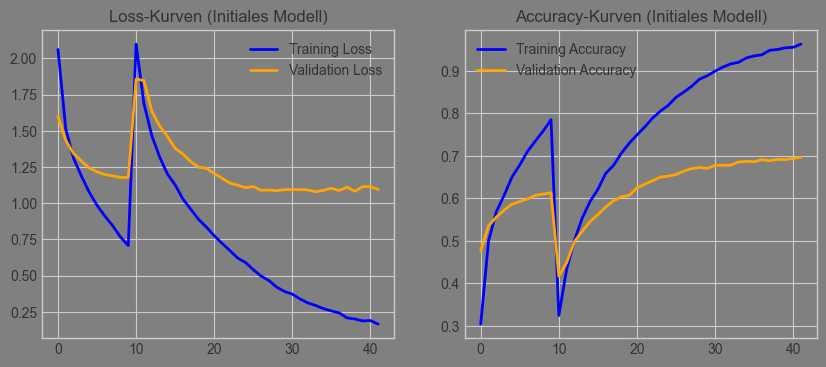


Numerische Daten der Trainingshistorie (Initiales Modell):


,Epoch,accuracy,loss,val_accuracy,val_loss
0,0,0.3041,2.0615,0.4769,1.6004
1,1,0.4993,1.5102,0.5355,1.4333
2,2,0.5688,1.3095,0.5558,1.3427
3,3,0.6074,1.1864,0.5725,1.2904
4,4,0.6501,1.0753,0.5861,1.2432



Initialmodell Test-Genauigkeit: 68.55 %

Starte Vorhersage auf Trainingsdaten zur Identifikation der 'Hard Examples'
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 54ms/step


In [6]:
if not 'df_history_initial' in locals():
    if os.path.exists(HISTORY_INITIAL_CSV):
        df_history_initial = pd.read_csv(HISTORY_INITIAL_CSV)
    else:
        history_data = models.history.history if hasattr(models, 'history') and models.history is not None else {}
        df_history_initial = pd.DataFrame(history_data)

if not df_history_initial.empty:
    plt.figure(figsize=[10, 4])
    plt.subplot(1, 2, 1)
    plt.plot(df_history_initial['loss'], color=PLOT_COLORS['primary'], linewidth=2.0, label='Training Loss')
    plt.plot(df_history_initial['val_loss'], color=PLOT_COLORS['secondary'], linewidth=2.0, label='Validation Loss')
    plt.legend()
    plt.title('Loss-Kurven (Initiales Modell)')

    plt.subplot(1, 2, 2)
    plt.plot(df_history_initial['accuracy'], color=PLOT_COLORS['primary'], linewidth=2.0, label='Training Accuracy')
    plt.plot(df_history_initial['val_accuracy'], color=PLOT_COLORS['secondary'], linewidth=2.0, label='Validation Accuracy')
    plt.legend()
    plt.title('Accuracy-Kurven (Initiales Modell)')
    plt.show()
    
    print("\nNumerische Daten der Trainingshistorie (Initiales Modell):")
    display(df_history_initial.round(4).head())

loss, accuracy = models.evaluate(test_images_norm, test_labels_sliced, verbose=0)
print(f"\nInitialmodell Test-Genauigkeit: {accuracy*100:.2f} %")

print("\nStarte Vorhersage auf Trainingsdaten zur Identifikation der 'Hard Examples'")
train_probabilities = models.predict(train_images_norm, verbose=1)
predicted_train_labels = np.argmax(train_probabilities, axis=1)
del train_probabilities

# 4. Optimiertes Modell (ResNet50_Optimize) - Training oder Laden ('Hard Examples')

Hard exemple hat wert auf 30% runter geschraubt darum ist der code zwar drin aber für mögliche weiterferwendung andere muster beibehalten

# 5. Analyse des optimierten Modells ('Hard Examples')

Hard exemple wurde nicht ausgefürt Übersprungen

# 6. EDA und zusätzliche Visualisierungen

## 6.1 EDA: Verteilung der Klassen

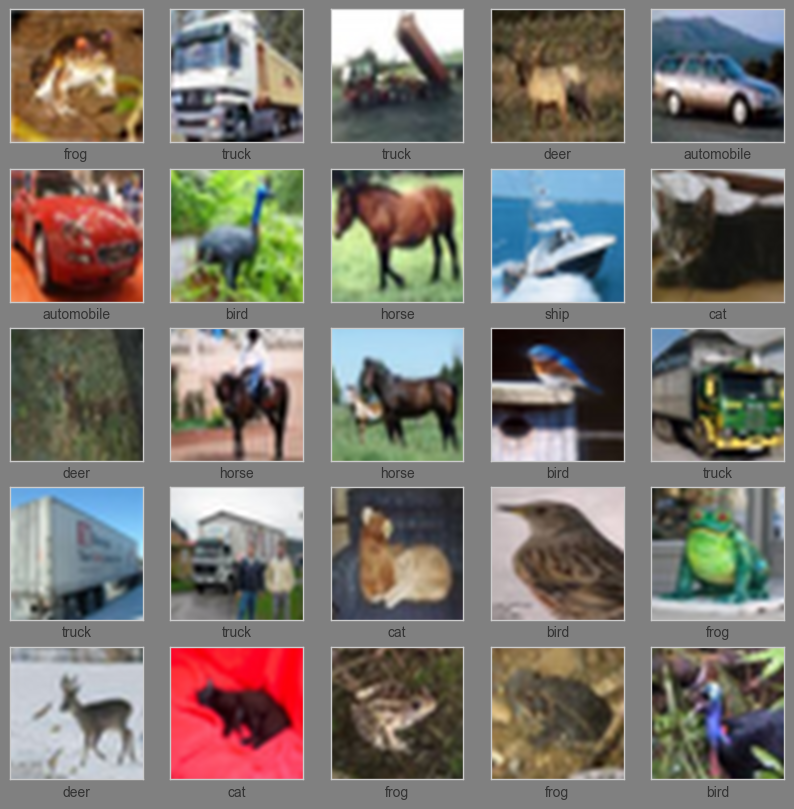


Anzahl der Bilder pro Klasse im Testdatensatz:


,Klasse,Anzahl
0,airplane,1000
1,automobile,1000
2,bird,1000
3,cat,1000
4,deer,1000
5,dog,1000
6,frog,1000
7,horse,1000
8,ship,1000
9,truck,1000



Anzahl der Bilder pro Klasse im Trainingsdatensatz'REDUZIERT von 50.000':


,Klasse,Anzahl
0,airplane,1005
1,automobile,974
2,bird,1032
3,cat,1016
4,deer,999
5,dog,937
6,frog,1030
7,horse,1001
8,ship,1025
9,truck,981


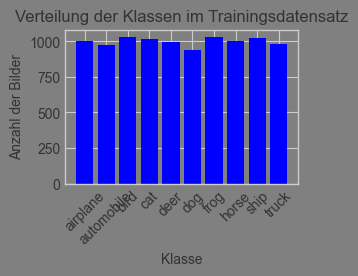

In [7]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images_sliced[i], interpolation='Lanczos', vmin=0, vmax=255)
    plt.xlabel(CLASS_NAMES[train_labels_sliced[i]])
plt.show()

# Zählung für den TESTDATENSATZ
unique_test, counts_test = np.unique(test_labels_sliced , return_counts=True)
df_class_counts_TEST = pd.DataFrame({'Klasse': [CLASS_NAMES[i] for i in unique_test],'Anzahl': counts_test})

# Zählung für den TRAINIGSDATENSATZ
unique_train, counts_train = np.unique(train_labels_sliced, return_counts=True)
df_class_counts_TRAIN = pd.DataFrame({'Klasse': [CLASS_NAMES[i] for i in unique_train],'Anzahl': counts_train})

print("\nAnzahl der Bilder pro Klasse im Testdatensatz:")
display(df_class_counts_TEST)
print("\nAnzahl der Bilder pro Klasse im Trainingsdatensatz'REDUZIERT von 50.000':")
display(df_class_counts_TRAIN)

plt.figure(figsize=(3, 2))
plt.bar(df_class_counts_TRAIN['Klasse'], df_class_counts_TRAIN ['Anzahl'], color=PLOT_COLORS['primary'])
plt.title('Verteilung der Klassen im Trainingsdatensatz')
plt.xlabel('Klasse')
plt.ylabel('Anzahl der Bilder')
plt.xticks(rotation=45)
plt.show()

## 6.2 Grid der falsch klassifizierten Bilder

In [13]:
# ANNAHME: plotly, go, Image und pd sind importiert und Variablen wie test_images_norm,
# CLASS_NAMES, test_labels_sliced, test_images_sliced, PLOT_COLORS sind definiert.
# Initialisiere df_ML, falls nicht vorhanden (gemäß Präferenz zur Speicherung von ML-Entscheidungen)
if 'df_ML' not in globals():
    df_ML = pd.DataFrame()

# 1. MODELLAUSWAHL & NEUE VORHERSAGE (Immer ausführen)

MODEL_TO_USE = model_optimized if 'model_optimized' in locals() and model_optimized is not None else models

# Bestimme den Modellnamen basierend auf der aktiven Trainingsphase (falls vorhanden)
if 'ACTIVE_RUN_NAME' in globals():
    MODEL_NAME = ACTIVE_RUN_NAME
elif 'model_optimized' in locals() and model_optimized is not None:
    MODEL_NAME = 'Optimiertes Modell'
else:
    MODEL_NAME = 'Initiales Modell'

print(f"Nutze Modell: {MODEL_NAME}")
print("Starte NEUE Vorhersage auf Testdaten...")

# Die VORHERSAGE WIRD NUN IMMER NEU BERECHNET!
probabilities = MODEL_TO_USE.predict(test_images_norm, verbose=1)
predicted_labels = np.argmax(probabilities, axis=1)

# Erstellen des aktuellen Analyse-DataFrames
df_analysis = pd.DataFrame({
    'model_name': MODEL_NAME,
    'true_label': test_labels_sliced.flatten(),
    'predicted_label': predicted_labels,
    'true_name': [CLASS_NAMES[i] for i in test_labels_sliced.flatten()],
    'pred_name': [CLASS_NAMES[i] for i in predicted_labels]
})
df_analysis['correct'] = df_analysis['true_label'] == df_analysis['predicted_label']
del probabilities

# 2. Speicherung in df_ML (Zwischenspeicher für Vergleich)
global df_ML
# Entferne alte Einträge dieses Modells, falls vorhanden
if 'model_name' in df_ML.columns:
    df_ML = df_ML[df_ML['model_name'] != MODEL_NAME]

# Füge die neuen Vorhersagen hinzu
df_ML = pd.concat([df_ML, df_analysis], ignore_index=True)

# 3. PLOTTING UND AUSWERTUNG

df_wrong = df_analysis[~df_analysis['correct']]
misclassified_indices = df_wrong.index.to_numpy()

fig = make_subplots(rows=len(CLASS_NAMES), cols=10, horizontal_spacing=0.01, vertical_spacing=0.01)
misclassification_counts_list = []

for class_idx, class_name in enumerate(CLASS_NAMES):
    specific_errors = [i for i in misclassified_indices if df_analysis.loc[i, 'predicted_label'] == class_idx]
    misclassification_counts_list.append(len(specific_errors))
    fig.update_yaxes(title_text=class_name, row=class_idx + 1, col=1)
    if not specific_errors: continue

    selected_indices = np.random.choice(specific_errors, size=min(10, len(specific_errors)), replace=False)
    for col_idx, img_idx in enumerate(selected_indices):
        image_pil = Image.fromarray(test_images_sliced[img_idx])
        upsampled_image = image_pil.resize((64, 64), Image.Resampling.LANCZOS)
        true_name = df_analysis.loc[img_idx, 'true_name']
        fig.add_trace(go.Image(z=np.array(upsampled_image), hoverinfo='name', name=f"Wahr: {true_name}"), row=class_idx + 1, col=col_idx + 1)
        fig.update_xaxes(showticklabels=False, row=class_idx + 1, col=col_idx + 1)
        fig.update_yaxes(showticklabels=False, row=class_idx + 1, col=col_idx + 1)

fig.update_layout(title=f"Falsch klassifizierte Bilder ({MODEL_NAME}, Zeilen: Vorhergesagte Klasse)", height=150 * len(CLASS_NAMES), width=1500, showlegend=False, paper_bgcolor=PLOT_COLORS['background'], plot_bgcolor=PLOT_COLORS['background'], font_color=PLOT_COLORS['text'])
# fig.write_html(MISCLASSIFIED_GRID_OPTIMIZED_HTML) # Speichern übersprungen
fig.show()

# Tabelle: Wie oft wurde eine Klasse fälschlicherweise vorhergesagt?
df_misclassification_summary = pd.DataFrame({'Vorhergesagtes_Label': CLASS_NAMES, 'Anzahl_Falscher_Vorhersagen': misclassification_counts_list})
print("\n### Tabelle: Wie oft wurde eine Klasse fälschlicherweise vorhergesagt?")
display(df_misclassification_summary)

# Gesamtauswertung
total_samples = len(df_analysis)
false_classified_count = len(df_wrong)
correctly_classified_count = total_samples - false_classified_count
df_evaluation = pd.DataFrame({
    'Status': ['Richtig erkannt', 'Falsch erkannt', 'Gesamt'],
    'Anzahl': [correctly_classified_count, false_classified_count, total_samples],
    'Prozent': [f"{(correctly_classified_count/total_samples)*100:.2f}%", f"{(false_classified_count/total_samples)*100:.2f}%", "100.00%"]
})
print("\n### Gesamtauswertung")
display(df_evaluation)

Nutze Modell: Initiales Modell
Starte NEUE Vorhersage auf Testdaten...
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 88ms/step



### Tabelle: Wie oft wurde eine Klasse fälschlicherweise vorhergesagt?


,Vorhergesagtes_Label,Anzahl_Falscher_Vorhersagen
0,airplane,269
1,automobile,227
2,bird,402
3,cat,452
4,deer,325
5,dog,360
6,frog,325
7,horse,293
8,ship,248
9,truck,244



### Gesamtauswertung


,Status,Anzahl,Prozent
0,Richtig erkannt,6855,68.55%
1,Falsch erkannt,3145,31.45%
2,Gesamt,10000,100.00%


## 6.3 Grid der korrekt klassifizierten Bilder

In [14]:
if 'df_analysis' not in locals():
    print("df_analysis nicht gefunden. Bitte führen Sie die Analyse-Zelle zuerst aus.")
else:
    correctly_classified_indices = df_analysis[df_analysis['correct']].index.to_numpy()
    fig = make_subplots(rows=len(CLASS_NAMES), cols=10, horizontal_spacing=0.01, vertical_spacing=0.01)
    correct_counts_list = []

    for class_idx, class_name in enumerate(CLASS_NAMES):
        specific_correct = [i for i in correctly_classified_indices if df_analysis.loc[i, 'true_label'] == class_idx]
        correct_counts_list.append(len(specific_correct))
        fig.update_yaxes(title_text=class_name, row=class_idx + 1, col=1)
        if not specific_correct: continue
        
        selected_indices = np.random.choice(specific_correct, size=min(10, len(specific_correct)), replace=False)
        for col_idx, img_idx in enumerate(selected_indices):
            fig.add_trace(go.Image(z=test_images_sliced[img_idx], hoverinfo='name', name=f"Wahr & Pred: {class_name}"), row=class_idx + 1, col=col_idx + 1)
            fig.update_xaxes(showticklabels=False, row=class_idx + 1, col=col_idx + 1)
            fig.update_yaxes(showticklabels=False, row=class_idx + 1, col=col_idx + 1)

    fig.update_layout(title="Korrekt klassifizierte Bilder (Zeilen: Wahre Klasse)", height=150 * len(CLASS_NAMES), width=1500, showlegend=False, paper_bgcolor=PLOT_COLORS['background'], plot_bgcolor=PLOT_COLORS['background'], font_color=PLOT_COLORS['text'])
    fig.write_html(CORRECTLY_CLASSIFIED_GRID_HTML)
    fig.show()

    df_correct_summary = pd.DataFrame({'Wahre_Klasse': CLASS_NAMES, 'Anzahl_Korrekt_Erkannt': correct_counts_list})
    print("\n### Tabelle: Anzahl korrekt erkannter Bilder pro Klasse")
    display(df_correct_summary)


### Tabelle: Anzahl korrekt erkannter Bilder pro Klasse


,Wahre_Klasse,Anzahl_Korrekt_Erkannt
0,airplane,720
1,automobile,771
2,bird,613
3,cat,505
4,deer,594
5,dog,591
6,frog,784
7,horse,707
8,ship,822
9,truck,748


# 7. Q&A - Detaillierte Einzelbild-Analyse

## 7.1 Bild nach Index auswählen

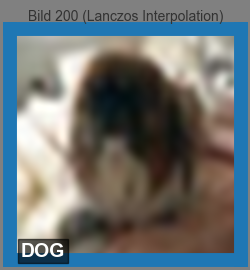

In [15]:
IMAGE_INDEX = 200
ORIGINAL_IMAGE = test_images[IMAGE_INDEX]

plt.figure(figsize=(3, 3))
plt.imshow(ORIGINAL_IMAGE, interpolation='Lanczos', vmin=0, vmax=255)
plt.title(f"Bild {IMAGE_INDEX} (Lanczos Interpolation)", fontsize=10)
plt.gcf().patch.set_facecolor(PLOT_COLORS['background'])
plt.xticks([]); plt.yticks([])
for spine in plt.gca().spines.values():
    spine.set_linewidth(10)
    spine.set_color(PLOT_COLORS['primary'])
plt.text(x=1, y=31, s=CLASS_NAMES[test_labels[IMAGE_INDEX].item()].upper(), color='white', fontsize=14, fontweight='bold', bbox=dict(facecolor='black', alpha=0.6, pad=2))
plt.show()

## 7.2 Ein Beispielbild pro Klasse

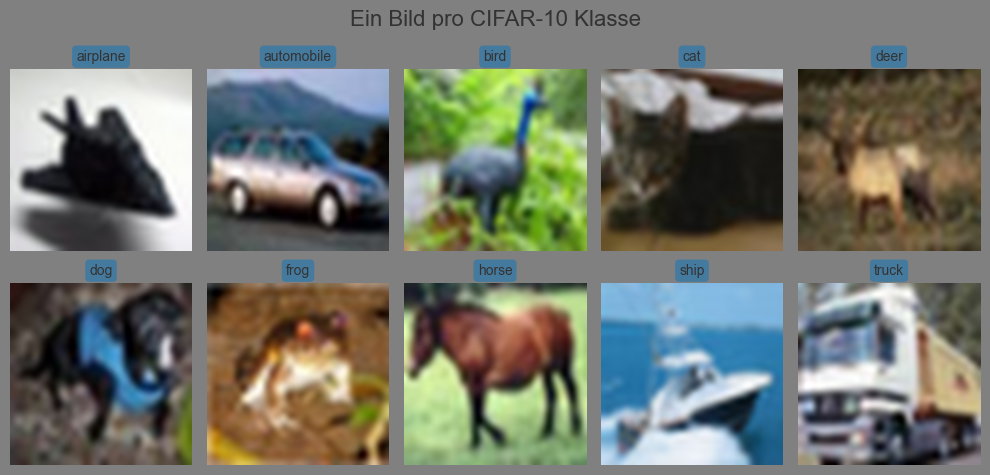

In [16]:
images_to_display = {}
for i, label_index in enumerate(train_labels_sliced):
    if label_index not in images_to_display:
        images_to_display[label_index] = train_images_sliced[i]
    if len(images_to_display) == len(CLASS_NAMES):
        break

sorted_images = sorted(images_to_display.items())

plt.figure(figsize=(10, 5))
plt.gcf().patch.set_facecolor(PLOT_COLORS['background'])

for i, (label_index, image) in enumerate(sorted_images):
    plt.subplot(2, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(image, interpolation='Lanczos', vmin=0, vmax=255)
    plt.xlabel(CLASS_NAMES[label_index], color=PLOT_COLORS['text'])
    plt.title(CLASS_NAMES[label_index], fontsize=10,color=PLOT_COLORS['text'], bbox=dict(facecolor=PLOT_COLORS['primary'], alpha=0.6, edgecolor='none', boxstyle='round,pad=0.3'))
    plt.axis("off")

plt.suptitle('Ein Bild pro CIFAR-10 Klasse', fontsize=16, color=PLOT_COLORS['text'])
plt.tight_layout()
plt.show()

## 7.3 Vorhersage-Wahrscheinlichkeiten für ein Bild

Vorhersagen für Bild Nummer 50 (Modell: Initial):
Tatsächliche Klasse: truck
---------------------------------------------
Klasse          |    Wahrscheinlichkeit (%)
---------------------------------------------
truck           |                    60.13% <--- PRED (WAHR)
airplane        |                    36.71%
bird            |                     1.76%
ship            |                     0.81%
deer            |                     0.27%
automobile      |                     0.18%
dog             |                     0.09%
cat             |                     0.04%
horse           |                     0.01%
frog            |                     0.00%
---------------------------------------------


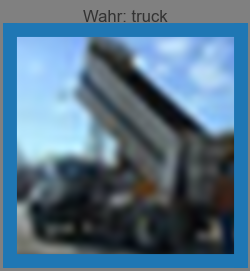

In [17]:
img_index = 50
selected_image = test_images_sliced[img_index]
true_label_idx = test_labels_sliced[img_index]

input_image = test_images_norm[img_index:img_index+1]
current_model = model_optimized if 'model_optimized' in locals() and model_optimized is not None else models
predictions = current_model.predict(input_image, verbose=0)
predicted_probabilities = predictions[0]

print(f"Vorhersagen für Bild Nummer {img_index} (Modell: {'Optimiert' if 'model_optimized' in locals() else 'Initial'}):")
print(f"Tatsächliche Klasse: {CLASS_NAMES[true_label_idx]}")
print("-" * 45)
print(f"{'Klasse':<15} | {'Wahrscheinlichkeit (%)':>25}")
print("-" * 45)
sorted_indices = np.argsort(predicted_probabilities)[::-1]
for i in sorted_indices:
    prob = predicted_probabilities[i]
    marker = " <--- PRED" if i == np.argmax(predicted_probabilities) else ""
    marker += f" (WAHR)" if i == true_label_idx else ""
    print(f"{CLASS_NAMES[i]:<15} | {prob * 100:>24.2f}%{marker}")
print("-" * 45)

plt.figure(figsize=(3,3))
plt.imshow(selected_image, interpolation='Lanczos', vmin=0, vmax=255)
plt.gcf().patch.set_facecolor(PLOT_COLORS['background'])
plt.xticks([])
plt.yticks([])
for spine in plt.gca().spines.values():
    spine.set_linewidth(10)
    spine.set_color(PLOT_COLORS['primary'])
plt.title(f"Wahr: {CLASS_NAMES[true_label_idx]}")
plt.show()

## 7.4 Einzelbild-Analyse mit Balkendiagramm

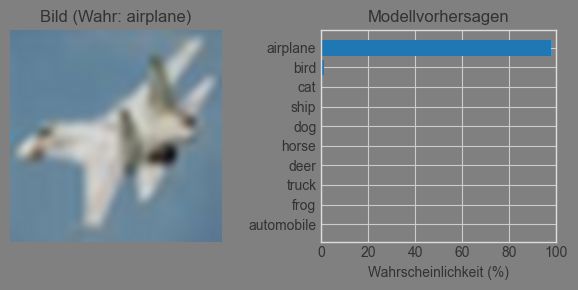

In [18]:
img_index = 10
selected_image = test_images_sliced[img_index]
true_label_idx = test_labels_sliced[img_index]

input_image = test_images_norm[img_index:img_index+1]
MODEL_TO_USE = model_optimized if 'model_optimized' in locals() and model_optimized is not None else models
probabilities = MODEL_TO_USE.predict(input_image, verbose=0)[0]
sorted_indices = np.argsort(probabilities)[::-1]
sorted_class_names = [CLASS_NAMES[i] for i in sorted_indices]
sorted_probabilities = probabilities[sorted_indices]

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
fig.patch.set_facecolor(PLOT_COLORS['background'])

ax[0].imshow(selected_image, interpolation='Lanczos', vmin=0, vmax=255)
ax[0].set_title(f"Bild (Wahr: {CLASS_NAMES[true_label_idx]})", color=PLOT_COLORS['text'])
ax[0].axis('off')

ax[1].barh(sorted_class_names, sorted_probabilities * 100, color=PLOT_COLORS['primary'])
ax[1].set_xlabel('Wahrscheinlichkeit (%)', color=PLOT_COLORS['text'])
ax[1].set_title('Modellvorhersagen', color=PLOT_COLORS['text'])
ax[1].set_xlim(0, 100)
ax[1].invert_yaxis()
ax[1].tick_params(colors=PLOT_COLORS['text'])
for spine in ax[1].spines.values():
    spine.set_color(PLOT_COLORS['grid'])

plt.tight_layout()
plt.show()

## 7.5 Detaillierte Vorhersagen für mehrere Bilder

Nutze Modell: Initial
Detaillierte Vorhersagen für mehrere Bilder:


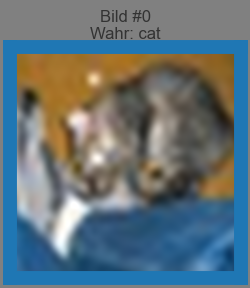

Vorhersagen für Bild #0 (Wahr: cat):
---------------------------------------------
Klasse          |    Wahrscheinlichkeit (%)
---------------------------------------------
cat             |                    98.36% <--- PRED
dog             |                     0.67%
frog            |                     0.32%
bird            |                     0.14%
automobile      |                     0.12%
horse           |                     0.10%
ship            |                     0.10%
airplane        |                     0.08%
truck           |                     0.08%
deer            |                     0.03%
--------------------------------------------- 



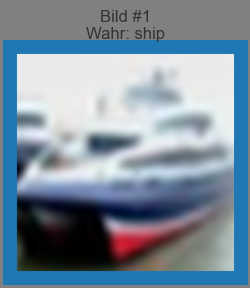

Vorhersagen für Bild #1 (Wahr: ship):
---------------------------------------------
Klasse          |    Wahrscheinlichkeit (%)
---------------------------------------------
ship            |                    99.98% <--- PRED
airplane        |                     0.01%
frog            |                     0.00%
bird            |                     0.00%
automobile      |                     0.00%
deer            |                     0.00%
truck           |                     0.00%
cat             |                     0.00%
dog             |                     0.00%
horse           |                     0.00%
--------------------------------------------- 



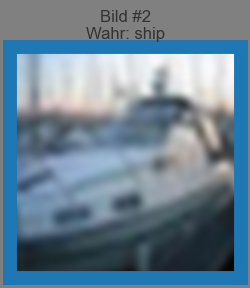

Vorhersagen für Bild #2 (Wahr: ship):
---------------------------------------------
Klasse          |    Wahrscheinlichkeit (%)
---------------------------------------------
ship            |                    99.93% <--- PRED
airplane        |                     0.02%
automobile      |                     0.02%
truck           |                     0.01%
frog            |                     0.01%
cat             |                     0.01%
deer            |                     0.01%
bird            |                     0.00%
dog             |                     0.00%
horse           |                     0.00%
--------------------------------------------- 



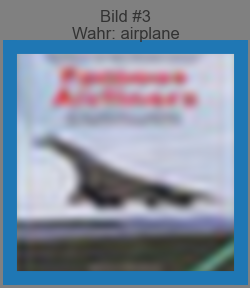

Vorhersagen für Bild #3 (Wahr: airplane):
---------------------------------------------
Klasse          |    Wahrscheinlichkeit (%)
---------------------------------------------
airplane        |                    55.26% <--- PRED
ship            |                    31.73%
truck           |                     9.65%
cat             |                     1.27%
bird            |                     0.52%
automobile      |                     0.42%
deer            |                     0.40%
dog             |                     0.35%
horse           |                     0.34%
frog            |                     0.06%
--------------------------------------------- 



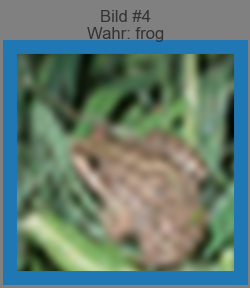

Vorhersagen für Bild #4 (Wahr: frog):
---------------------------------------------
Klasse          |    Wahrscheinlichkeit (%)
---------------------------------------------
bird            |                    41.64% <--- PRED
deer            |                    22.97%
frog            |                    19.61%
cat             |                     7.44%
ship            |                     2.15%
airplane        |                     1.88%
dog             |                     1.49%
horse           |                     1.40%
truck           |                     0.98%
automobile      |                     0.44%
--------------------------------------------- 



In [19]:
MODEL_TO_USE = model_optimized if 'model_optimized' in locals() and model_optimized is not None else models
NUM_IMAGES_TO_CHECK = 5

print(f"Nutze Modell: {'Optimiert' if 'model_optimized' in locals() else 'Initial'}")
print("Detaillierte Vorhersagen für mehrere Bilder:")
for i in range(NUM_IMAGES_TO_CHECK):
    img_index = i
    selected_image_display = test_images_sliced[img_index]
    selected_image_pred = test_images_norm[img_index]
    true_label_index = test_labels_sliced[img_index]
    true_label_name = CLASS_NAMES[true_label_index]

    input_image = np.expand_dims(selected_image_pred, axis=0)
    probabilities = MODEL_TO_USE.predict(input_image, verbose=0)[0]
    sorted_indices = np.argsort(probabilities)[::-1]

    plt.figure(figsize=(3,3))
    plt.imshow(selected_image_display, interpolation='Lanczos', vmin=0, vmax=255)
    plt.title(f"Bild #{img_index}\nWahr: {true_label_name}")
    plt.gcf().patch.set_facecolor(PLOT_COLORS['background'])
    plt.xticks([])
    plt.yticks([])
    for spine in plt.gca().spines.values():
        spine.set_linewidth(10)
        spine.set_color(PLOT_COLORS['primary'])
    plt.show()

    print(f"Vorhersagen für Bild #{img_index} (Wahr: {true_label_name}):")
    print("-" * 45)
    print(f"{'Klasse':<15} | {'Wahrscheinlichkeit (%)':>25}")
    print("-" * 45)
    for idx in sorted_indices:
        marker = " <--- PRED" if idx == sorted_indices[0] else ""
        print(f"{CLASS_NAMES[idx]:<15} | {probabilities[idx] * 100:>24.2f}%{marker}")
    print("-" * 45, "\n")
    del probabilities

## 7.6 Detaillierte Verwechslungs-Analyse (Plotly)

In [20]:
if 'df_analysis' in locals():
    df_wrong = df_analysis[~df_analysis['correct']].copy()
    
    if not df_wrong.empty:
        df_confusions = df_wrong.groupby(['true_name', 'pred_name']).size().reset_index(name='count')
        df_confusions['rank'] = df_confusions.groupby('true_name')['count'].rank(method='first', ascending=False)
        
        TOP_K = 10
        df_top_confusions = df_confusions[df_confusions['rank'] <= TOP_K].copy()
        
        df_all_classes = pd.DataFrame({'true_name': CLASS_NAMES})
        df_plot_data = pd.merge(df_all_classes, df_top_confusions, on='true_name', how='left')
        df_plot_data['count'] = df_plot_data['count'].fillna(0)
        df_plot_data['pred_name'] = df_plot_data['pred_name'].fillna('Kein Fehler')
        df_plot_data['true_name'] = pd.Categorical(df_plot_data['true_name'], categories=CLASS_NAMES, ordered=True)

        fig_all_conf = px.bar(
            df_plot_data,
            y="pred_name",
            x="count",
            color="pred_name",
            facet_col="true_name",
            facet_col_wrap=len(CLASS_NAMES),
            facet_row_spacing=0.01,
            facet_col_spacing=0.01,
            title=f"Top {TOP_K} Fehlklassifikationen pro wahrer Klasse",
            labels={"pred_name": "Vorhergesagte Klasse", "count": "Anzahl der Fehler", "true_name": "Wahre Klasse"},
            category_orders={"true_name": CLASS_NAMES}
        )

        for ann in fig_all_conf.layout.annotations:
            if isinstance(ann.text, str) and "=" in ann.text:
                ann.text = ann.text.split("=", 1)[1].strip()
            ann.font.size = 14

        fig_all_conf.update_layout(
            showlegend=False,
            height=450,
            width=1600,
            title=dict(font=dict(size=18), y=0.98, yanchor="top"),
            margin=dict(t=80, b=80, l=60, r=20),
            paper_bgcolor=PLOT_COLORS['background'],
            plot_bgcolor=PLOT_COLORS['background'],
            font_color=PLOT_COLORS['text']
        )

        fig_all_conf.for_each_xaxis(lambda axis: axis.update(tickfont=dict(size=10), title_font=dict(size=12)))
        fig_all_conf.for_each_yaxis(lambda axis: axis.update(tickfont=dict(size=10), title_font=dict(size=12), categoryorder='array', categoryarray=CLASS_NAMES))
        fig_all_conf.show()
        fig_all_conf.write_html(CONFUSION_ANALYSIS_HTML)
        print(f"\n✅ Interaktiver Plot gespeichert: {CONFUSION_ANALYSIS_HTML}")
        print("\nTabelle der Top-Fehlklassifikationen pro wahrer Klasse:")
        display(df_top_confusions.head())
    else:
        print("🎉 Perfekt! Keine Fehler gefunden.")
else:
    print("ℹ️ df_analysis nicht gefunden. Analyse wird übersprungen.")



✅ Interaktiver Plot gespeichert: Ablagerung/artifacts_ml/optimized_model_confusion_analysis.html

Tabelle der Top-Fehlklassifikationen pro wahrer Klasse:


,true_name,pred_name,count,rank
0,airplane,automobile,20,4.0
1,airplane,bird,59,2.0
2,airplane,cat,15,7.0
3,airplane,deer,18,6.0
4,airplane,dog,7,8.0


---

# Weitere Modelle ML

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, RandomFlip, RandomRotation, RandomTranslation
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Reshape, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam

# 0. KONFIGURATION UND VARIABLEN-DEFINITION

MODEL_NAME_HYBRID_32 = "Hybrid_CNN_LSTM_32x32"

# Erstellen des verbesserten Hybrid-Modells
if os.path.exists(HYBRID_MODEL_PATH_32):
    print(f"Lade Modell von '{HYBRID_MODEL_PATH_32}'...")
    model = load_model(HYBRID_MODEL_PATH_32)
    print("✅ Modell geladen.")
else:
    print(f"Kein Modell gefunden. Definiere und trainiere ein neues {MODEL_NAME_HYBRID_32}...")

    model = Sequential([
        Input(shape=(32, 32, 3)),

        # Augmentierungs-Schichten
        RandomFlip("horizontal"),
        RandomRotation(0.1),
        RandomTranslation(height_factor=0.1, width_factor=0.1),

        # CNN- und LSTM-Teile
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Reshape((16 * 16, 32)),
        LSTM(128, return_sequences=False),
        Dropout(0.3),
        Dense(10, activation='softmax')
    ])

    # Kompilieren des Modells
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    #model.summary()

    # TRAINING
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
    checkpoint = ModelCheckpoint(filepath=HYBRID_MODEL_PATH_32, monitor='val_loss', save_best_only=True, verbose=1)

    print(f"\nStarte Training des Hybrid-Modells ({MODEL_NAME_HYBRID_32})...")

    history_hybrid = model.fit(train_images_norm, test_labels_sliced, # Korrektur des Fehlers: train_labels (50.000 Samples)
                                epochs=50,
                                validation_data=(test_images_norm, test_labels_sliced),
                                callbacks=[early_stopping, checkpoint, TqdmCallback(verbose=1)],
                                verbose=0
                                )

    print(f"\n✅ Training abgeschlossen. Bestes Modell in '{HYBRID_MODEL_PATH_32}' gespeichert.")


# 2. FINALE BEWERTUNG UND DATENABLAGE (df_ML_HYBRID_32)

# 3. Finale Bewertung der Qualität
test_loss, test_acc = model.evaluate(test_images_norm, test_labels_sliced, verbose=1)

# 4. Speichern der Ergebnisse in df_ML_HYBRID_32 (Datenbank der Entscheidungen)
if 'df_ML_HYBRID_32' not in locals() and 'df_ML_HYBRID_32' not in globals():
    df_ML_HYBRID_32 = pd.DataFrame(columns=['Modell', 'Datensatz', 'Verlust (Loss)', 'Genauigkeit (Accuracy)'])

new_entry = pd.DataFrame([{
    'Modell': MODEL_NAME_HYBRID_32,
    'Datensatz': 'Test (32x32)', # Klarer Daten-Kontext
    'Verlust (Loss)': test_loss,
    'Genauigkeit (Accuracy)': test_acc
}])
df_ML_HYBRID_32 = pd.concat([df_ML_HYBRID_32, new_entry], ignore_index=True)

# Ausgabe der aktualisierten Datenbank (Tabelle mit numerischen Daten)
print(f'\nGenauigkeit des {MODEL_NAME_HYBRID_32} Modells: {test_acc*100:.2f}%')
print("\n📋 Aktualisierte Datenbank der ML-Entscheidungen (df_ML):")
df_ML_HYBRID_32

In [ ]:
# Erstellen des verbesserten Hybrid-Modells qualytät bewertung
# Setup für das Hybrid-Modell
MISCLASSIFIED_GRID_HYBRID_HTML = 'misclassified_grid_hybrid_lstm.html'
PLOT_COLORS = {'background': 'lightgray', 'text': 'black'} # Beispiel
# MODEL_TO_USE wird hier auf das trainierte Hybrid-Modell (model) gesetzt

# 1. Modellauswahl (Nutzt das gerade trainierte 'model')
MODEL_TO_USE = model
print(f"Nutze Modell: Hybrid_CNN_LSTM (Zuvor trainiert)")

# 2. Starte Vorhersage und erstelle df_analysis
if 'df_analysis_hybrid' not in locals():
    print("Starte Vorhersage auf Testdaten...")
    # verbose=1, um den Fortschrittsbalken zu sehen (Ihre Präferenz)
    probabilities = MODEL_TO_USE.predict(test_images_norm, verbose=1)
    predicted_labels = np.argmax(probabilities, axis=1)

    # Stelle sicher, dass test_labels_sliced 1D ist
    true_labels_flat = test_labels_sliced.flatten()

    df_analysis_hybrid = pd.DataFrame({
        'true_label': true_labels_flat, 'predicted_label': predicted_labels,
        'true_name': [CLASS_NAMES[i] for i in true_labels_flat],
        'pred_name': [CLASS_NAMES[i] for i in predicted_labels]
    })
    df_analysis_hybrid['correct'] = df_analysis_hybrid['true_label'] == df_analysis_hybrid['predicted_label']
    del probabilities

# 3. Fehlerdaten extrahieren
df_wrong = df_analysis_hybrid[~df_analysis_hybrid['correct']]
misclassified_indices = df_wrong.index.to_numpy()

# 4. Erstelle Plotly-Figur für die falsch klassifizierten Bilder
fig = make_subplots(rows=len(CLASS_NAMES), cols=10, horizontal_spacing=0.01, vertical_spacing=0.01)
misclassification_counts_list = []

for class_idx, class_name in enumerate(CLASS_NAMES):
    # Finde Fehler, wo die vorhergesagte Klasse == class_idx ist
    specific_errors = df_wrong[df_wrong['predicted_label'] == class_idx].index.to_list()
    misclassification_counts_list.append(len(specific_errors))
    fig.update_yaxes(title_text=class_name, row=class_idx + 1, col=1)
    if not specific_errors: continue

    selected_indices = np.random.choice(specific_errors, size=min(10, len(specific_errors)), replace=False)

    for col_idx, img_idx in enumerate(selected_indices):
        image_pil = Image.fromarray(test_images[img_idx])
        upsampled_image = image_pil.resize((64, 64), Image.Resampling.LANCZOS)
        true_name = df_analysis_hybrid.loc[img_idx, 'true_name']

        fig.add_trace(go.Image(z=np.array(upsampled_image), hoverinfo='name', name=f"Wahr: {true_name}"),
                      row=class_idx + 1, col=col_idx + 1)
        fig.update_xaxes(showticklabels=False, row=class_idx + 1, col=col_idx + 1)
        fig.update_yaxes(showticklabels=False, row=class_idx + 1, col=col_idx + 1)

fig.update_layout(title="Falsch klassifizierte Bilder (Zeilen: Vorhergesagte Klasse)",
                  height=150 * len(CLASS_NAMES), width=1500, showlegend=False,
                  paper_bgcolor=PLOT_COLORS['background'], plot_bgcolor=PLOT_COLORS['background'],
                  font_color=PLOT_COLORS['text'])
fig.write_html(MISCLASSIFIED_GRID_HYBRID_HTML)
# fig.show() # Wird im Muster als Kommentar gehalten

# 5. Erstellung der Tabellen (Qualität der gelernten Merkmale)
df_misclassification_summary = pd.DataFrame({
    'Vorhergesagtes_Label': CLASS_NAMES,
    'Anzahl_Falscher_Vorhersagen': misclassification_counts_list
})

total_samples = len(df_analysis_hybrid)
false_classified_count = len(df_wrong)
correctly_classified_count = total_samples - false_classified_count

df_evaluation = pd.DataFrame({
    'Status': ['Richtig erkannt', 'Falsch erkannt', 'Gesamt'],
    'Anzahl': [correctly_classified_count, false_classified_count, total_samples],
    'Prozent': [f"{(correctly_classified_count/total_samples)*100:.2f}%",
                f"{(false_classified_count/total_samples)*100:.2f}%", "100.00%"]
})

print("\n### Tabelle: Wie oft wurde eine Klasse fälschlicherweise vorhergesagt (df_misclassification_summary)")
# Füge die Ausgabe-Funktion hinzu
display(df_misclassification_summary)

print("\n### Gesamtauswertung (df_evaluation)")
# Füge die Ausgabe-Funktion hinzu
display(df_evaluation)

In [ ]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, RandomFlip, RandomRotation, RandomTranslation
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Reshape, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tqdm.keras import TqdmCallback

# 0. KONFIGURATION
# HYBRID_MODEL_PATH_64 wird aus dem Setup verwendet!
MODEL_NAME_HYBRID_64 = "Hybrid_CNN_LSTM_64x64"

# 1. HOCHSKALIERUNG (Pre-Processing)
def upsample_lanczos(images, new_size=(64, 64)):
    import tensorflow as tf
    resized_images = tf.image.resize(
        images,
        new_size,
        method=tf.image.ResizeMethod.LANCZOS3
    )
    # Konvertierung und Normalisierung
    return resized_images.numpy() / 255.0

# Führe die Hochskalierung und Normalisierung in einem Schritt durch
train_images_norm_64 = upsample_lanczos(train_images_sliced)
test_images_norm_64 = upsample_lanczos(test_images_sliced)

print(f"Bilder erfolgreich auf 64x64 normalisiert. Trainings-Shape: {train_images_norm_64.shape}")

# 2. MODELL LADEN ODER DEFINIEREN/TRAINIEREN

if os.path.exists(HYBRID_MODEL_PATH_64):
    print(f"Lade Modell von '{HYBRID_MODEL_PATH_64}'...")
    model = load_model(HYBRID_MODEL_PATH_64)
    print("✅ Modell geladen.")
else:
    print(f"Kein Modell gefunden. Definiere und trainiere ein neues {MODEL_NAME_HYBRID_64}...")

    # Modell-Definition (Angepasst an 64x64)
    model = Sequential([
        Input(shape=(64, 64, 3)),

        # Augmentierungs-Schichten
        RandomFlip("horizontal"),
        RandomRotation(0.1),
        RandomTranslation(height_factor=0.1, width_factor=0.1),

        # CNN-Teil
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)), # Reduziert 64x64 auf 32x32

        # Transformation für das LSTM
        Reshape((32 * 32, 32)),

        # LSTM-Teil
        LSTM(128, return_sequences=False),

        # Regularisierung
        Dropout(0.3),

        # Ausgabeschicht
        Dense(10, activation='softmax')
    ])

    # Kompilieren des Modells
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    model.summary()

    # TRAINING
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
    checkpoint = ModelCheckpoint(filepath=HYBRID_MODEL_PATH_64, monitor='val_loss', save_best_only=True, verbose=1)

    print(f"\nStarte Training des Hybrid-Modells ({MODEL_NAME_HYBRID_64})...")

    history_hybrid = model.fit(train_images_norm_64, test_labels_sliced,
                                epochs=50,
                                validation_data=(test_images_norm_64, test_labels_sliced),
                                callbacks=[early_stopping, checkpoint, TqdmCallback(verbose=1)],
                                verbose=0
                                )

    print(f"\n✅ Training abgeschlossen. Bestes Modell in '{HYBRID_MODEL_PATH_64}' gespeichert.")


# 3. FINALE BEWERTUNG UND DATENABLAGE (df_ML)

# 3. Finale Bewertung der Qualität
test_loss, test_acc = model.evaluate(test_images_norm_64, test_labels_sliced, verbose=1)

# 4. Speichern der Ergebnisse in df_ML
if 'df_ML' not in locals() and 'df_ML' not in globals():
    df_ML = pd.DataFrame(columns=['Modell', 'Datensatz', 'Verlust (Loss)', 'Genauigkeit (Accuracy)'])

new_entry = pd.DataFrame([{
    'Modell': MODEL_NAME_HYBRID_64,
    'Datensatz': 'Test (64x64)',
    'Verlust (Loss)': test_loss,
    'Genauigkeit (Accuracy)': test_acc
}])

df_ML = pd.concat([df_ML, new_entry], ignore_index=True)

# Ausgabe der aktualisierten Datenbank
print(f'\nGenauigkeit des {MODEL_NAME_HYBRID_64} Modells: {test_acc*100:.2f}%')
print("\n📋 Aktualisierte Datenbank der ML-Entscheidungen (df_ML):")
df_ML

In [ ]:
# Erstellen des verbesserten Hybrid-Modells qualytät bewertung
# Setup für das Hybrid-Modell
MISCLASSIFIED_GRID_HYBRID_HTML = 'misclassified_grid_hybrid_lstm.html'

# 1. Modellauswahl
MODEL_TO_USE = model
print(f"Nutze Modell: Hybrid_CNN_LSTM (Zuvor trainiert)")

# 2. Starte Vorhersage und erstelle df_analysis
if 'df_analysis_hybrid' not in locals():
    print("Starte Vorhersage auf Testdaten...")
    probabilities = MODEL_TO_USE.predict(test_images_norm, verbose=1)
    predicted_labels = np.argmax(probabilities, axis=1)
    true_labels_flat = test_labels_sliced.flatten()

    df_analysis_hybrid = pd.DataFrame({
        'true_label': true_labels_flat, 'predicted_label': predicted_labels,
        'true_name': [CLASS_NAMES[i] for i in true_labels_flat],
        'pred_name': [CLASS_NAMES[i] for i in predicted_labels]
    })
    df_analysis_hybrid['correct'] = df_analysis_hybrid['true_label'] == df_analysis_hybrid['predicted_label']
    del probabilities

# 3. Fehlerdaten extrahieren
df_wrong = df_analysis_hybrid[~df_analysis_hybrid['correct']]
misclassified_indices = df_wrong.index.to_numpy()

# 4. Erstelle Plotly-Figur für die falsch klassifizierten Bilder
fig = make_subplots(rows=len(CLASS_NAMES), cols=10, horizontal_spacing=0.01, vertical_spacing=0.01)
misclassification_counts_list = []

for class_idx, class_name in enumerate(CLASS_NAMES):
    specific_errors = df_wrong[df_wrong['predicted_label'] == class_idx].index.to_list()
    misclassification_counts_list.append(len(specific_errors))
    fig.update_yaxes(title_text=class_name, row=class_idx + 1, col=1)
    if not specific_errors: continue

    selected_indices = np.random.choice(specific_errors, size=min(10, len(specific_errors)), replace=False)

    for col_idx, img_idx in enumerate(selected_indices):
        image_pil = Image.fromarray(test_images[img_idx])
        upsampled_image = image_pil.resize((64, 64), Image.Resampling.LANCZOS)
        true_name = df_analysis_hybrid.loc[img_idx, 'true_name']

        fig.add_trace(go.Image(z=np.array(upsampled_image), hoverinfo='name', name=f"Wahr: {true_name}"),
                      row=class_idx + 1, col=col_idx + 1)
        fig.update_xaxes(showticklabels=False, row=class_idx + 1, col=col_idx + 1)
        fig.update_yaxes(showticklabels=False, row=class_idx + 1, col=col_idx + 1)

fig.update_layout(title="Falsch klassifizierte Bilder (Zeilen: Vorhergesagte Klasse)",
                  height=150 * len(CLASS_NAMES), width=1500, showlegend=False,
                  paper_bgcolor=PLOT_COLORS['background'], plot_bgcolor=PLOT_COLORS['background'],
                  font_color=PLOT_COLORS['text'])
fig.write_html(MISCLASSIFIED_GRID_HYBRID_HTML)
# fig.show()

# 5. Erstellung der Tabellen
df_misclassification_summary = pd.DataFrame({
    'Vorhergesagtes_Label': CLASS_NAMES,
    'Anzahl_Falscher_Vorhersagen': misclassification_counts_list
})

total_samples = len(df_analysis_hybrid)
false_classified_count = len(df_wrong)
correctly_classified_count = total_samples - false_classified_count

df_evaluation = pd.DataFrame({
    'Status': ['Richtig erkannt', 'Falsch erkannt', 'Gesamt'],
    'Anzahl': [correctly_classified_count, false_classified_count, total_samples],
    'Prozent': [f"{(correctly_classified_count/total_samples)*100:.2f}%",
                f"{(false_classified_count/total_samples)*100:.2f}%", "100.00%"]
})

print("\n### Tabelle: Wie oft wurde eine Klasse fälschlicherweise vorhergesagt (df_misclassification_summary)")
display(df_misclassification_summary)

print("\n### Gesamtauswertung (df_evaluation)")
display(df_evaluation)

# LabelMe: Ein Werkzeug zur Bildannotation

- pip3 install labelme
- labelme

# LEICHEN

In [ ]:
# HARD EXAMPLE IDENTIFIZIERUNG
# ANNAHMEN (MÜSSEN IM KONTEXT IHRES NOTEBOOKS EXISTIEREN)
# -----------------------------------------------------------------------------
# models:                       Das VORHERIG trainierte Gesamtmodell (Phase 1 & 2).
# train_images_norm:            Die normalisierten Trainingsdaten (z.B. 50000, 32, 32, 3).
# train_labels_sliced:          Die korrespondierenden Labels (One-Hot oder Integer-codiert).
# CLASS_NAMES:                  Liste der Klassennamen (z.B. ['Flugzeug', ...]).
# OPTIMIZED_MODEL_PATH:         Dateipfad zum Speichern des Hard-Mining-Modells.
# HISTORY_OPTIMIZED_CSV:        Dateipfad zum Speichern der Hard-Mining-Historie.
# -----------------------------------------------------------------------------

# 🔍 1. Hard Example Identifizierung (Vorbereitung)

print("\nStarte Vorhersage auf Trainingsdaten zur Identifikation der 'Hard Examples'")

# 1. Berechne Vorhersagen des Basis-Modells (models) auf Trainingsdaten.
if 'predicted_train_labels' not in locals():
    print("Berechne Vorhersagen des Basis-Modells (models) auf Trainingsdaten...")
    train_probabilities = models.predict(train_images_norm, verbose=1)
    predicted_train_labels = np.argmax(train_probabilities, axis=1)
    del train_probabilities

# 2. Indizes der falsch klassifizierten Beispiele (Hard Examples)
if len(train_labels_sliced.shape) > 1 and train_labels_sliced.shape[1] > 1:
    true_train_labels = np.argmax(train_labels_sliced, axis=1)
else:
    true_train_labels = train_labels_sliced.flatten()

hard_example_indices = np.where(true_train_labels != predicted_train_labels)[0]

# 3. Extrahiere die Hard Examples
X_train_hard = train_images_norm[hard_example_indices]
y_train_hard = true_train_labels[hard_example_indices]
print(f"Anzahl identifizierter 'Hard Examples': {len(X_train_hard)}")

## 2. Modell Definition und Training auf Hard Examples (Phase 3)
if os.path.exists(OPTIMIZED_MODEL_PATH):
    print(f"Lade optimiertes Modell von '{OPTIMIZED_MODEL_PATH}'...")
    model_optimized = load_model(OPTIMIZED_MODEL_PATH)
    print("✅ Optimiertes Modell geladen.")

else:
    print("Kein optimiertes Modell gefunden. Trainiere auf 'Hard Examples'...")
    model_optimized = None

    try:
        # 1. FEATURE EXTRACTOR (ResNet50 Basis) laden und einfrieren
        base_model_optimize = RESNET50(
            include_top=False,
            weights='imagenet',
            input_shape=train_images_norm.shape[1:]
        )
        base_model_optimize.trainable = False


        # MODELL-DEFINITION MIT SEQUENTIAL API (WIE VON IHNEN GEWÜNSCHT)

        model_optimized = Sequential([
            Input(shape=(32, 32, 3)),
            # 2. VORVERARBEITUNGS-KETTE (Exakt wie in Ihrem Initial-Modell)
            resizing_layer64,
            data_augmentation_layer,
            color_pooling_layer,
            resizing_layer32,
            edge_contour_layer,
            center_mask_layer,
            resnet_preprocessor_layer,
            #combined_color_boost_layer,
            #gaussian_filter_layer,

            # 3. FEATURE EXTRACTOR (ResNet50)
            models.layers[models.layers.index(models.get_layer('resnet50'))],
            # 4. KLASSIFIKATIONS-HEAD (NEU FÜR HARD MINING)
            GlobalAveragePooling2D(),
            Dense(256, activation='relu'),# kernel_regularizer=l2(0.00001)),
            BatchNormalization(),
            Activation('relu'),
            Dropout(0.1),
            Dense(64, activation='relu'),# kernel_regularizer=l2(0.00001)),
            BatchNormalization(),
            Activation('relu'),
            Dropout(0.1),
            Dense(len(CLASS_NAMES), activation='softmax', name="HardMining_Output")
        ])

        # 5. GEWICHTE KOPIEREN
        # Kopiere alle Gewichte (außer dem letzten Layer) von 'models' auf 'model_optimized'
        for i in range(len(models.layers) - 1): # Gehe alle Layer bis zum letzten durch
            model_optimized.layers[i].set_weights(models.layers[i].get_weights())

        # 6. FEINABSTIMMUNGSEINSTELLUNGEN WIEDERHERSTELLEN
        resnet_layer_new = model_optimized.get_layer('resnet50')
        resnet_layer_new.trainable = True
        for layer in resnet_layer_new.layers[:-Auschliesung_datenbank]:
            layer.trainable = False

        # Jetzt wird nur der neue letzte Layer trainiert (Hard Mining)
        model_optimized._name = "ResNet50_HardMining"
        df_ML_Model = model_optimized
        print("✅ Modell-Architektur erfolgreich aus Basismodell geklont und Head neu initialisiert.")

    except Exception as e:
        print(f"\n❌ FEHLER BEI DER MODELLDEFINITION GEFUNDEN: {e}")
        print("\n--- Fehleranalyse ---")
        print("Überprüfen Sie, ob der Name des ResNet-Layers in Ihrem Initialmodell 'resnet50' ist.")
        model_optimized = None

    # 5. Kompilieren und Training
    if model_optimized:
        model_optimized.compile(
            optimizer=Adam(learning_rate=0.0001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        print("✅ Neues Hard-Mining-Modell kompiliert.")


        early_stopping_opt = EarlyStopping(monitor='val_loss',
                                           patience=8,
                                           restore_best_weights=True,
                                           verbose=1)

        checkpoint_opt = ModelCheckpoint(filepath=OPTIMIZED_MODEL_PATH,
                                         monitor='val_loss',
                                         save_best_only=True,
                                         verbose=1)

        if len(X_train_hard) > 0:
            #models.summary(expand_nested=False)
            batch_size_opt = max(1, min(64, len(X_train_hard)))
            print(f"Starte Training auf {len(X_train_hard)} Hard Examples mit Batch Size {batch_size_opt}...")

            history_optimize = model_optimized.fit(
                X_train_hard,
                y_train_hard,
                epochs=50,
                batch_size=batch_size_opt,
                validation_split=0.1,
                callbacks=[early_stopping_opt, checkpoint_opt, TqdmCallback(verbose=1)],
                verbose=0
            )

            print(f"\n✅ Training abgeschlossen. Modell in '{OPTIMIZED_MODEL_PATH}' gespeichert.")

            # 7. Datenablage und df_ML Finalisierung
            df_history_optimized = pd.DataFrame(history_optimize.history)
            df_history_optimized.to_csv(HISTORY_OPTIMIZED_CSV, index=False)
            print(f"✅ Trainingshistorie in '{HISTORY_OPTIMIZED_CSV}' gespeichert.")
            df_ML_Model = model_optimized # Finalisierung der Speicherung

        else:
            print("⚠️ Keine Hard Examples gefunden! Training wird übersprungen.")

In [ ]:
MODEL_NAME = "ResNet50_optimize_TransferLearning"
# 1. Bewertung des Modells
test_loss, test_acc = model_optimized.evaluate(test_images_norm, test_labels_sliced, verbose=0)
print(f'\nGenauigkeit auf den Testdaten ({MODEL_NAME}): {test_acc*100:.2f}%')

In [ ]:
# optimiertes Modells ResNet50_optimize
if 'model_optimized' in locals() and model_optimized is not None:
    if not 'df_history_optimized' in locals():
        if os.path.exists(HISTORY_OPTIMIZED_CSV):
            df_history_optimized = pd.read_csv(HISTORY_OPTIMIZED_CSV)
        else:
            df_history_optimized = pd.DataFrame()

    if not df_history_optimized.empty:
        plt.figure(figsize=[10, 4])
        plt.subplot(1, 2, 1)
        plt.plot(df_history_optimized['loss'], color=PLOT_COLORS['primary'], label='Training Loss')
        plt.plot(df_history_optimized['val_loss'], color=PLOT_COLORS['secondary'], label='Validation Loss')
        plt.legend()
        plt.title('Loss-Kurven (Optimiert)')
        plt.subplot(1, 2, 2)
        plt.plot(df_history_optimized['accuracy'], color=PLOT_COLORS['primary'], label='Training Accuracy')
        plt.plot(df_history_optimized['val_accuracy'], color=PLOT_COLORS['secondary'], label='Validation Accuracy')
        plt.legend()
        plt.title('Accuracy-Kurven (Optimiert)')
        plt.tight_layout()
        plt.show()

        print("\nNumerische Daten der Trainingshistorie (Optimiertes Modell):")
        display(df_history_optimized.round(4).head())

    loss_opt, accuracy_opt = model_optimized.evaluate(test_images_norm, test_labels_sliced, verbose=0)
    print(f"\nOptimiertes Modell Test-Genauigkeit: {accuracy_opt:.4f}")

    print("\nStarte Vorhersage auf Testdaten mit optimiertem Modell...")
    probabilities_opt = model_optimized.predict(test_images_norm, verbose=1)
    predicted_labels_opt = np.argmax(probabilities_opt, axis=1)

    df_analysis = pd.DataFrame({
        'true_label': test_labels_sliced.flatten(),
        'predicted_label': predicted_labels_opt,
        'true_name': [CLASS_NAMES[i] for i in test_labels_sliced.flatten()],
        'pred_name': [CLASS_NAMES[i] for i in predicted_labels_opt]
    })
    df_analysis['correct'] = df_analysis['true_label'] == df_analysis['predicted_label']

    del probabilities_opt

    df_wrong = df_analysis[~df_analysis['correct']]
    if not df_wrong.empty:
        df_confusions = df_wrong.groupby(['true_name', 'pred_name']).size().reset_index(name='count')
        df_confusions['rank'] = df_confusions.groupby('true_name')['count'].rank(method='first', ascending=False)
        df_top_confusions = df_confusions[df_confusions['rank'] <= 5]

        fig_conf = px.bar(df_top_confusions, x="pred_name", y="count", color="pred_name", facet_col="true_name", facet_col_wrap=5, title="Top 5 Fehlklassifikationen pro wahrer Klasse", category_orders={"true_name": CLASS_NAMES})
        fig_conf.update_layout(showlegend=False, paper_bgcolor=PLOT_COLORS['background'], plot_bgcolor=PLOT_COLORS['background'], font_color=PLOT_COLORS['text'])
        fig_conf.update_xaxes(row="all", col="all", categoryorder='array', categoryarray=CLASS_NAMES, title_text='Vorhergesagte Klasse')
        fig_conf.show()
        fig_conf.write_html(CONFUSION_ANALYSIS_HTML)
        print(f"✅ Interaktiver Plot in '{CONFUSION_ANALYSIS_HTML}' gespeichert.")

        print("\nTabelle der Top-Fehlklassifikationen:")
        display(df_top_confusions.head())
    else:
        print("🎉 Perfekt! Keine Fehler gefunden.")
else:
    print("ℹ️ Optimiertes Modell wurde nicht trainiert oder geladen. Analyse wird übersprungen.")